WHO > [The Global Health Observatory: Explore a world of health data](https://www.who.int/data/gho/data/themes/topics/indicator-groups/indicator-group-details/GHO/life-expectancy-and-healthy-life-expectancy)<br />
WHO > [Life expectancy at birth](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years))<br />
WHO > [Healthy life expectancy (HALE) at birth](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/gho-ghe-hale-healthy-life-expectancy-at-birth)<br />

Lists of countries by life expectancy: [world](https://en.wikipedia.org/wiki/List_of_countries_by_life_expectancy) <i>([template](https://en.wikipedia.org/wiki/Template:List_of_countries_by_life_expectancy/World_Health_Organization))</i>, [Europe](https://en.wikipedia.org/wiki/List_of_European_countries_by_life_expectancy), [Asia](https://en.wikipedia.org/wiki/List_of_Asian_countries_by_life_expectancy), [North America](https://en.wikipedia.org/wiki/List_of_North_American_countries_by_life_expectancy), [South America](https://en.wikipedia.org/wiki/List_of_South_American_countries_by_life_expectancy), [Americas (combined)](https://en.wikipedia.org/wiki/List_of_countries_in_the_Americas_by_life_expectancy), [Africa](https://en.wikipedia.org/wiki/List_of_African_countries_by_life_expectancy), [regions](https://en.wikipedia.org/wiki/List_of_world_regions_by_life_expectancy), [EU](https://en.wikipedia.org/wiki/Demographics_of_the_European_Union#Life_expectancy)<br />
[my private wiki-page for exploration](https://en.wikipedia.org/wiki/User:Lady3mlnm/HALE)<br>
Списки стран по ожидаемой продолжительности жизни: [мир в целом](https://ru.wikipedia.org/wiki/Список_стран_по_ожидаемой_продолжительности_жизни), [Европа](https://ru.wikipedia.org/wiki/Список_стран_Европы_по_ожидаемой_продолжительности_жизни), [Азия](https://ru.wikipedia.org/wiki/Список_стран_Азии_по_ожидаемой_продолжительности_жизни), [Северная Америка](https://ru.wikipedia.org/wiki/Список_стран_Южной_Америки_по_ожидаемой_продолжительности_жизни), [Северная Америка](https://ru.wikipedia.org/wiki/Список_стран_Южной_Америки_по_ожидаемой_продолжительности_жизни),  [Африка](https://ru.wikipedia.org/wiki/Список_стран_Африки_по_ожидаемой_продолжительности_жизни), [регионы](https://ru.wikipedia.org/wiki/Список_регионов_мира_по_ожидаемой_продолжительности_жизни), [ЕС](https://ru.wikipedia.org/wiki/Население_стран_Европейского_союза#Продолжительность_жизни), [СНГ](https://ru.wikipedia.org/wiki/Содружество_Независимых_Государств#Социальное_развитие_стран_СНГ)<br />
[Список государств и зависимых территорий по населению](https://ru.wikipedia.org/wiki/Список_государств_и_зависимых_территорий_по_населению)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from data_service.dictionary_eng_rus_for_barcharts import dd_to_rus  # dictionary for translation of names

In [3]:
pd.options.display.max_rows = 20
pd.options.display.min_rows = 6
# pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.2f}'.format

DESTINATION_OUTPUT = 'show'  # to where table code should be placed: 'file', 'show' or, otherwise' just print 'Done'
YEAR_SELECTED = 2019
LANG = 'en'

In [4]:
LS_COUNTRIES_EXAMPLES = ['Russia', 'USA', 'France', 'Spain', 'Japan', 'Switzerland', 'South Korea', 'world']

In [5]:
# LS_WHO_REGIONS = ['Africa', 'Americas', 'Eastern Mediterranean', 'Europe', 'South-East Asia', 'Western Pacific']
# LS_INCOME_GROUPS = ['High-income', 'Upper-middle-income', 'Lower-middle-income', 'Low-income']

In [6]:
def output_table_code(st, file_name='', destination=''):
    if not destination:
        destination = DESTINATION_OUTPUT
        
    if destination == 'file':
        with open('output-barcharts/'+file_name, 'w', encoding="utf-8") as fh:
            fh.write(st)
        print('Data has written to file')
    elif destination == 'show':
        print(st)
    else:
        print('done')

In [7]:
dd_countries_renaming = {
	'Bolivia (Plurinational State of)': 'Bolivia',
	'Brunei Darussalam': 'Brunei',
	'Cabo Verde': 'Cape Verde',
	"Democratic People's Republic of Korea": 'North Korea',
	'Democratic Republic of the Congo': 'DR Congo',
    'Congo': 'Republic of\nCongo',
	'Iran (Islamic Republic of)': 'Iran',
	"Lao People's Democratic Republic": 'Laos',
	'Micronesia (Federated States of)': 'Micronesia',
	'Netherlands (Kingdom of the)': 'Netherlands',
	'Republic of Korea': 'South Korea',
	'Republic of Moldova': 'Moldova',
	'Russian Federation': 'Russia',
	'Syrian Arab Republic': 'Syria',
    'Türkiye': 'Turkey',
    "Cote d'Ivoire": 'Côte d\'Ivoire',
    'United Arab Emirates': 'UAE',
	'United Kingdom of Great Britain and Northern Ireland': 'UK',
	'United Republic of Tanzania': 'Tanzania',
	'United States of America': 'USA',
	'Central African Republic': 'CAR',
	'Venezuela (Bolivarian Republic of)': 'Venezuela',
    'Viet Nam': 'Vietnam',
    'Saint Vincent and the Grenadines': 'St. Vincent and the Grenadines',
	'occupied Palestinian territory, including east Jerusalem': 'occupied Palestinian territory',
	'Dominican Republic': 'Dominican\nRepublic',
    'Trinidad and Tobago': 'Trinidad &\nTobago',
	'Papua New Guinea': 'Papua\nNew Guinea',
	'Bosnia and Herzegovina': 'Bosnia &\nHerzegovina',
    'North Macedonia': 'North\nMacedonia',
    'South-East Asia': 'South-East\nAsia',
    'Eastern Mediterranean': 'Eastern\nMediterranean',
    'Western Pacific': 'Western\nPacific',
    'High-income': 'countries with\nhigh\nincome',
    'Upper-middle-income': 'countries with\nupper-middle\nincome',
    'Lower-middle-income': 'countries with\nlower-middle\nincome',
    'Low-income': 'countries with\nlow\nincome',
    'Global': 'world'
}

In [8]:
def load_data_from_csv(file_name_core, selected_indicator, selected_year, prefix_for_cols):

    def load_single_csv(file_name):
        return pd.read_csv(f"data/{file_name}", usecols=['Indicator', 'Location', 'Period', 'Dim1', 'FactValueNumeric'])


    df = pd.concat([load_single_csv(f"{file_name_core} -countries.csv"),
                    load_single_csv(f"{file_name_core} -global.csv"),
                    load_single_csv(f"{file_name_core} -regions.csv"),
                    load_single_csv(f"{file_name_core} -income_groups.csv")])


    df.rename(columns={'Location': 'country',
                       'Period': 'year',
                       'Dim1': 'sex',
                       'FactValueNumeric': 'value'}, inplace=True)
    
    df = df[(df.Indicator == selected_indicator) & (df.year == selected_year)] \
              .drop(columns=['Indicator', 'year'])
            
    df['country'] = df['country'].replace(dd_countries_renaming)
    df = df.pivot(index='country', columns='sex', values='value')
    df = df[['Both sexes', 'Male', 'Female']]                       # just reorder
    df.rename(columns = {'Both sexes': f"{prefix_for_cols}_o",
                         'Male': f"{prefix_for_cols}_m",
                         'Female': f"{prefix_for_cols}_f"}, inplace=True)
    df.index.name = ''
    df.columns.name = ''
    df[f"{prefix_for_cols}_fΔm"] = (df[f"{prefix_for_cols}_f"] - df[f"{prefix_for_cols}_m"]).round(2)

    return df


df_le = load_data_from_csv(file_name_core="Life expectancy at birth",
                           selected_indicator="Life expectancy at birth (years)",
                           selected_year=YEAR_SELECTED, prefix_for_cols='LE')
df_le.loc[LS_COUNTRIES_EXAMPLES].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm
,,,,
Japan,84.47,81.70,87.15,5.45
South Korea,83.69,80.56,86.56,6.00
Switzerland,83.48,81.76,85.12,3.36
Spain,83.14,80.54,85.66,5.12
France,82.53,79.77,85.15,5.38
USA,78.74,76.53,80.98,4.45
Russia,73.22,68.17,78.00,9.83
world,73.12,70.61,75.70,5.09


In [9]:
df_hale = load_data_from_csv(file_name_core="Healthy life expectancy (HALE) at birth",
                             selected_indicator="Healthy life expectancy (HALE) at birth (years)",
                             selected_year=YEAR_SELECTED, prefix_for_cols='HALE')
df_hale.loc[LS_COUNTRIES_EXAMPLES].sort_values(by='HALE_o', ascending=False)

,HALE_o,HALE_m,HALE_f,HALE_fΔm
,,,,
Japan,73.58,72.09,75.01,2.92
South Korea,72.50,70.62,74.19,3.57
Spain,71.69,70.90,72.42,1.52
Switzerland,71.53,71.33,71.67,0.34
France,70.72,69.78,71.60,1.82
USA,66.02,65.13,66.93,1.80
Russia,63.72,60.41,66.84,6.43
world,63.45,62.33,64.59,2.26


In [10]:
# concatenate two dataFrames
df = pd.concat([df_le, df_hale], axis='columns')
df['ratio_HALE_LE'] = 100 * df['HALE_o'] / df['LE_o']
print(df.shape)
df.loc[LS_COUNTRIES_EXAMPLES].sort_values(by='LE_o', ascending=False)

(196, 9)


,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Japan,84.47,81.70,87.15,5.45,73.58,72.09,75.01,2.92,87.11
South Korea,83.69,80.56,86.56,6.00,72.50,70.62,74.19,3.57,86.63
Switzerland,83.48,81.76,85.12,3.36,71.53,71.33,71.67,0.34,85.69
Spain,83.14,80.54,85.66,5.12,71.69,70.90,72.42,1.52,86.23
France,82.53,79.77,85.15,5.38,70.72,69.78,71.60,1.82,85.69
USA,78.74,76.53,80.98,4.45,66.02,65.13,66.93,1.80,83.85
Russia,73.22,68.17,78.00,9.83,63.72,60.41,66.84,6.43,87.03
world,73.12,70.61,75.70,5.09,63.45,62.33,64.59,2.26,86.78


<br>
<br>

In [12]:
def process_chart_result(plt, lang=LANG, destination=DESTINATION_OUTPUT, file_name=None):
    if destination == 'file':
        plt.savefig(f"output-barcharts/{file_name}{' -ru' if lang=='ru' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)  
        print('Data has written to file')
    else:
        plt.show()

In [13]:
# def create_categories_for_wiki(ls:list):
#     for country in ls:
#         print(f"[[Category:Life expectancy charts for {country}]]")

In [14]:
def compare_countries(df, ls_countries, columns_sorting=['LE_o', 'HALE_o'], figure_size=(28, 8),
                      lang=LANG, title_en='', title_ru='',
                      label_rotation=90, value_precision=1, size_text_on_chart='x-large',
                      destination=DESTINATION_OUTPUT, file_name='LE'):
    plt.rcParams['figure.figsize'] = figure_size

    df = df.loc[ls_countries]                                          # filter given dataframe
    print(f"Number of items: {len(df)}")
    df.sort_values(by=columns_sorting, ascending=False, inplace=True)  # sort dataframe

    fig, ax = plt.subplots()

    ax.set_title(label=title_ru if lang=='ru' else title_en, fontsize=14)  # set title

    ax.tick_params(axis='x', pad=1.5)                                  # set where ticks and labels will be shown around charts
    ax.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=True, pad=1.5)

    major_ticks = range(0, 91, 10)     # major ticks every 10 years on y-axe
    minor_ticks = range(0, 91, 5)      # minor ticks every  5 years on y-axe
    
    ax.set_yticks(ticks=major_ticks, labels = list(major_ticks[:-1]) + [''])  # the chart is more clear if we don't place label '90' on y-axis  # ax.set_yticks(major_ticks)
    ax.set_yticks(minor_ticks, minor=True)
    
    ax.grid(which='minor', axis='y', color='grey', linewidth=0.25)  # settle grid
    ax.grid(which='major', axis='y', color='grey', linewidth=0.5)

    plt.xticks(fontsize=15, rotation=label_rotation)   # set labels on axes, labels of countries are rotated to 90 degrees
    plt.yticks(fontsize=13)
    
    if lang=='ru':                 # if language is Russian than translate labels
        ax.set_xticks(ticks=list(range(len(df))), labels = (dd_to_rus[name] for name in df.index))

    plt.ylim(0, 90)                # limit chat by y-axis
    plt.xlim(-0.55, len(df)-0.45)  # remove gaps between bars and vertical edges of the chart

    bar_hale = plt.bar(df.index, df['HALE_o'], color='green', zorder=20, width=0.9, edgecolor='black', linewidth=0.75, label='ОПЗЖ' if lang=='ru' else 'HALE')
    bar_le = plt.bar(df.index, df['LE_o'], color='orange', zorder=10, width=0.9, edgecolor='black', linewidth=0.75, label='ОПЖ в плохим здоровьем' if lang=='ru' else 'LE with disability')

    # Add text with LE and HALE values
    for rect in bar_le:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0 +0.01, height-1.2, f'{height:.{value_precision}f}',
                 ha='center', va='top', zorder=30, fontsize=size_text_on_chart)

    for rect in bar_hale:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0 +0.01, height-1.2, f'{height:.{value_precision}f}',
                 ha='center', va='top', zorder=30, fontsize=size_text_on_chart,
                 color='white', weight='bold')
        
    ax.legend(loc='upper right', ncol=2, fontsize=11.25)  # add legend

    process_chart_result(plt, lang=lang, destination=destination, file_name=file_name)
    
    # create_categories_for_wiki(df.index.to_list())
    
    return None

In [15]:
def compare_countries_by_sex(df, ls_countries, columns_sorting=['LE_o', 'HALE_o'], figure_size=(28, 8),
                             lang=LANG, title_en='', title_ru='', short_legend=False, hide_upper_label=False,
                             label_rotation=90, value_precision=1, size_text_on_chart='large',
                             destination=DESTINATION_OUTPUT, file_name='LE'):
    plt.rcParams['figure.figsize'] = figure_size

    df = df.loc[ls_countries]                                          # filter given dataframe
    df.sort_values(by=columns_sorting, ascending=False, inplace=True)  # sort dataframe

    fig, ax = plt.subplots()

    ax.set_title(label=title_ru if lang=='ru' else title_en, fontsize=14)  # set title

    ax.tick_params(axis='x', pad=1.5)                                  # set where ticks and labels will be shown around charts
    ax.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=True, pad=1.5)

    major_ticks = range(0, 96, 10)     # major ticks every 10 years on y-axe
    minor_ticks = range(0, 96, 5)      # minor ticks every  5 years on y-axe
    
    if hide_upper_label:  # hide upper label in this is required
        ax.set_yticks(ticks=major_ticks, labels = list(major_ticks[:-1]) + [''])
    else:
        ax.set_yticks(major_ticks)
    ax.set_yticks(minor_ticks, minor=True)
    
    ax.grid(which='minor', axis='y', color='grey', linewidth=0.25)  # settle grid
    ax.grid(which='major', axis='y', color='grey', linewidth=0.5)

    plt.xticks(fontsize=15, rotation=label_rotation)   # set labels on axes, labels of countries are rotated to 90 degrees
    plt.yticks(fontsize=13)
    
    # ax.set_yticks(major_ticks)  # ax.set_yticks(ticks=major_ticks, labels = list(major_ticks[:-1]) + [''])  # the chart is more clear if we don't place label '90' on y-axis
    ax.set_xticks(ticks=list(range(len(df))), labels = (dd_to_rus[name] for name in df.index) if lang=='ru' else df.index)

    plt.ylim(0, 95)                # limit chat by y-axis
    plt.xlim(-0.55, len(df)-0.45)  # remove gaps between bars and vertical edges of the chart
    
    # Place bar charts
    shift = 0.35
    if not short_legend:  # value 'short_legend' determines different order of items in the legend
        bar_m_hale = plt.bar([x-shift/2 for x in range(len(df))], df['HALE_m'], color='blue', zorder=20, width=shift, edgecolor='black', linewidth=0.75, label='ОПЗЖ для мужчин' if lang=='ru' else 'HALE for male')
        bar_m_le = plt.bar([x-shift/2 for x in range(len(df))], df['LE_m'], color='paleturquoise', zorder=10, width=shift, edgecolor='black', linewidth=0.75, label= 'ОПЖ в плохим здоровье для мужчин' if lang=='ru' else 'LE with disability for male')
        bar_f_hale = plt.bar([x+shift/2 for x in range(len(df))], df['HALE_f'], color='red', zorder=20, width=shift, edgecolor='black', linewidth=0.75, label='ОПЖЗ для женщин' if lang=='ru' else 'HALE for female')
        bar_f_le = plt.bar([x+shift/2 for x in range(len(df))], df['LE_f'], color='mistyrose', zorder=10, width=shift, edgecolor='black', linewidth=0.75, label='ОПЖ в плохим здоровье для женщин' if lang=='ru' else 'LE with disability for female')
    else:
        bar_m_le = plt.bar([x-shift/2 for x in range(len(df))], df['LE_m'], color='paleturquoise', zorder=10, width=shift, edgecolor='black', linewidth=0.75, label='ОПЖ в плохим здоровье для мужчин' if lang=='ru' else 'LE with disability for male')
        bar_m_hale = plt.bar([x-shift/2 for x in range(len(df))], df['HALE_m'], color='blue', zorder=20, width=shift, edgecolor='black', linewidth=0.75, label='ОПЗЖ для мужчин' if lang=='ru' else 'HALE for male')
        bar_f_le = plt.bar([x+shift/2 for x in range(len(df))], df['LE_f'], color='mistyrose', zorder=10, width=shift, edgecolor='black', linewidth=0.75, label='ОПЖ в плохим здоровье для женщин' if lang=='ru' else 'LE with disability for female')
        bar_f_hale = plt.bar([x+shift/2 for x in range(len(df))], df['HALE_f'], color='red', zorder=20, width=shift, edgecolor='black', linewidth=0.75, label='ОПЖЗ для женщин' if lang=='ru' else 'HALE for female')

    # Add text with LE and HALE values
    for rect, rect_hale in zip(bar_m_le, bar_m_hale):
        le = rect.get_height()   # height-1.2
        hale = rect_hale.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0 +0.045, 3.6,
                 f'{hale:.{value_precision}f} | {le:.{value_precision}f}',
                 ha='center', va='bottom', zorder=30, fontsize=size_text_on_chart,
                 color='white', rotation='vertical')

    for rect, rect_hale in zip(bar_f_le, bar_f_hale):
        le = rect.get_height()   # height-1.2
        hale = rect_hale.get_height()
        plt.text(rect.get_x() + rect.get_width() / 2.0 +0.05, 3.6,
                 f'{hale:.{value_precision}f} | {le:.{value_precision}f}',
                 ha='center', va='bottom', zorder=30, fontsize=size_text_on_chart,
                 color='black', rotation='vertical')

    
    ax.legend(loc='upper right', ncol=2 if short_legend else 4, fontsize=11.25)  # add legend
    
    process_chart_result(plt, lang=lang, destination=destination, file_name=file_name)
    
    return None

<br />
<br />

**world**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population#Sovereign_states_and_dependencies_by_population),
[list according to UN](https://en.wikipedia.org/wiki/List_of_countries_by_population_(United_Nations))

In [17]:
ls_countries = ['Algeria', 'Argentina', 'Australia', 'Bangladesh', 'Brazil', 'China', 'Colombia', 'DR Congo', 'Egypt', 'Ethiopia',
                'France', 'Germany', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Italy', 'Japan', 'Kenya', 'Mexico', 'Myanmar',
                'Nigeria', 'Pakistan', 'Philippines', 'Russia', 'Saudi Arabia', 'South Africa', 'South Korea', 'Spain', 'Sudan',
                'Tanzania', 'Thailand', 'Turkey', 'UAE', 'UK', 'USA', 'Uganda', 'Ukraine', 'Vietnam']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Japan,84.47,81.70,87.15,5.45,73.58,72.09,75.01,2.92,87.11
South Korea,83.69,80.56,86.56,6.00,72.50,70.62,74.19,3.57,86.63
Spain,83.14,80.54,85.66,5.12,71.69,70.90,72.42,1.52,86.23
...,...,...,...,...,...,...,...,...,...
South Africa,65.84,62.50,68.85,6.35,56.29,54.65,57.73,3.08,85.50
Nigeria,63.07,61.68,64.51,2.83,54.81,54.68,54.95,0.27,86.90
DR Congo,61.84,59.67,64.08,4.41,53.50,52.46,54.59,2.13,86.51


Number of items: 40


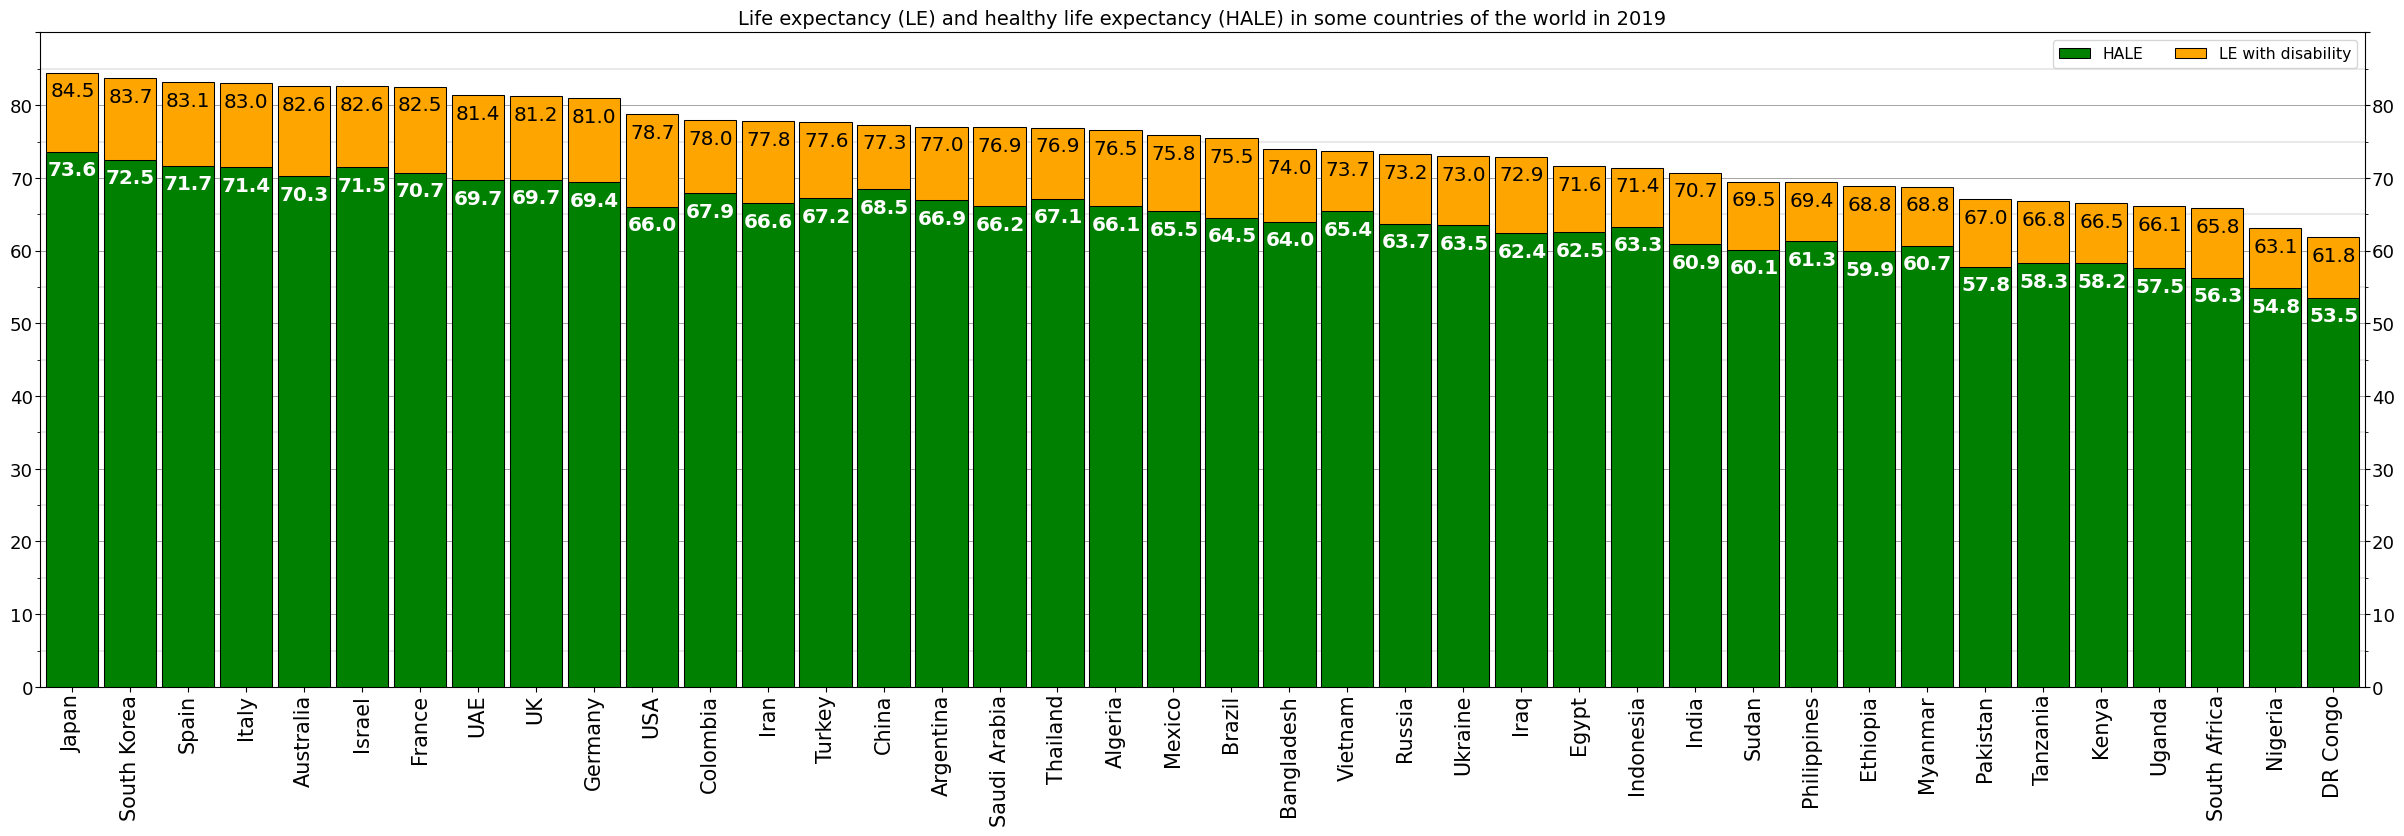

In [18]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(30, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in some countries of the world in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в некоторых странах мира в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -world')

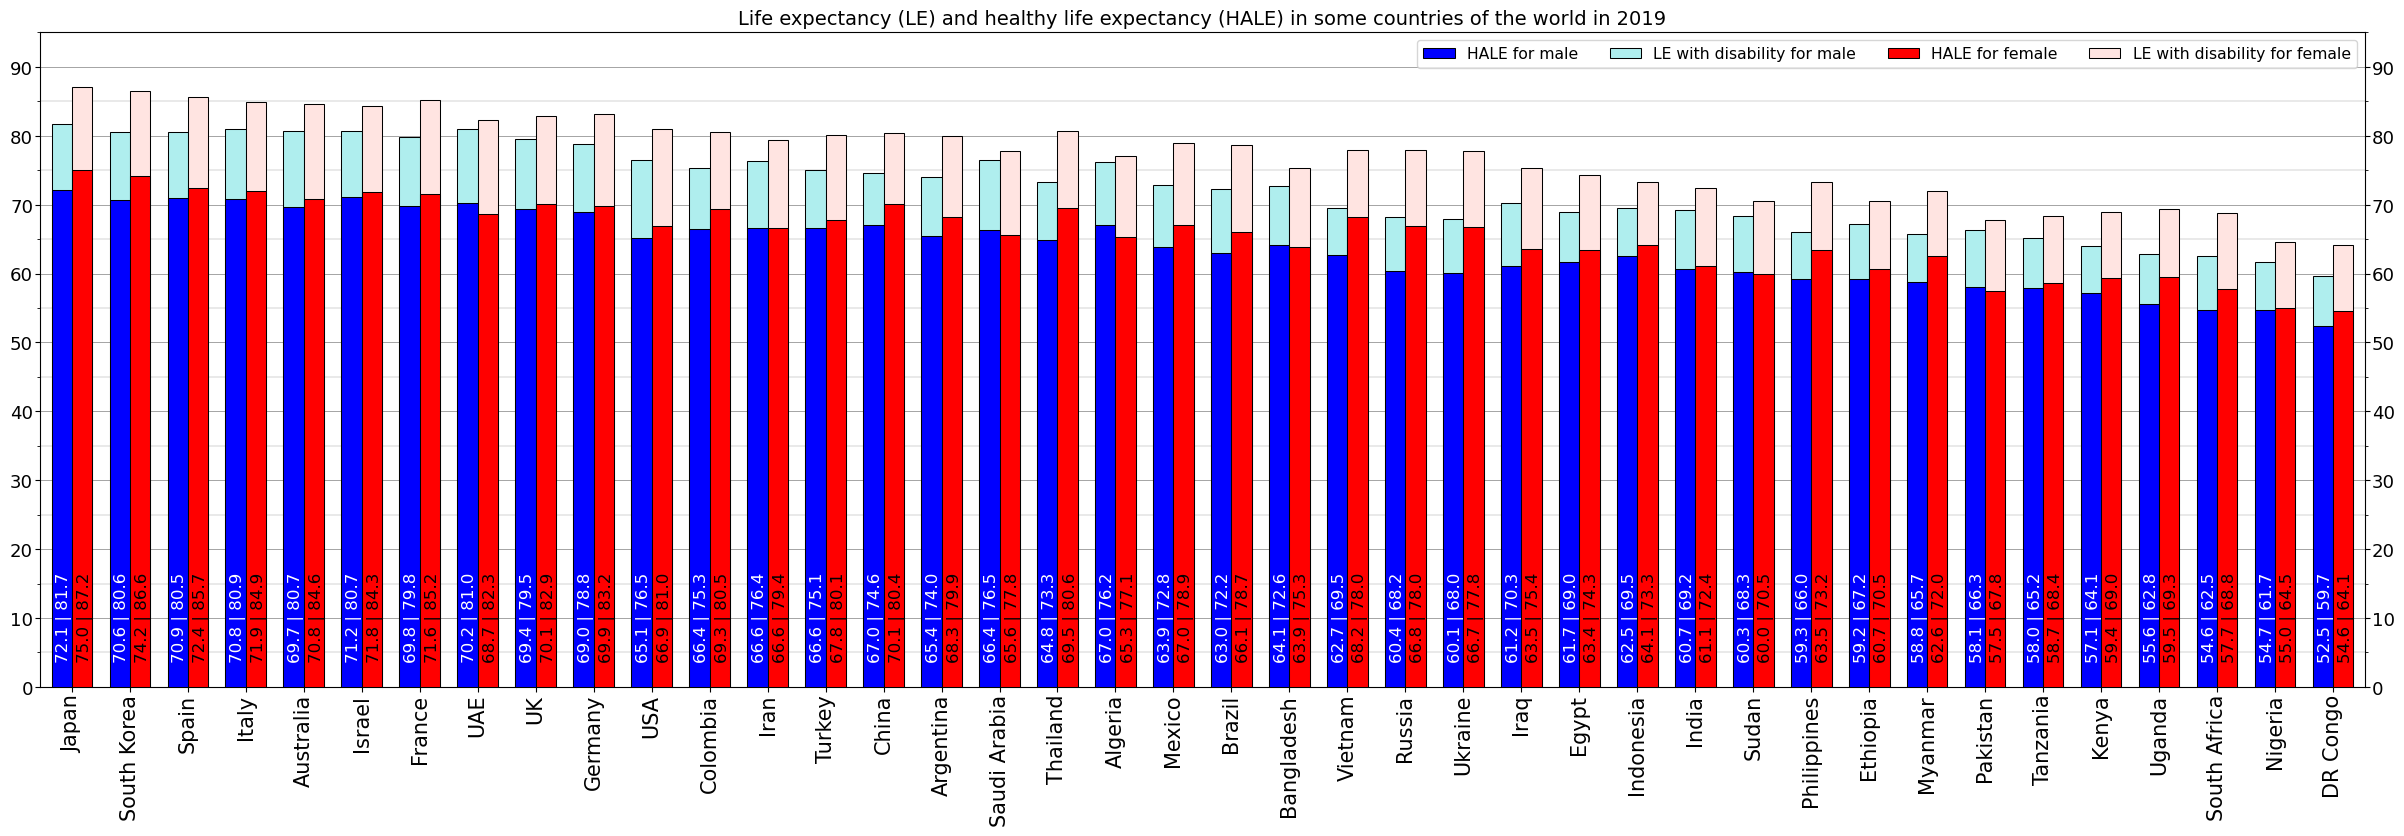

In [19]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -world -sex')

<br />
<br />

**Europe**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_European_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_European_countries_by_population#Table),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_Europe#Sovereign_states)

In [21]:
ls_countries = ['Albania', 'Austria', 'Belarus', 'Belgium', 'Bosnia &\nHerzegovina', 'Bulgaria', 'Croatia', 'Czechia',
                'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy',
                'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Montenegro', 'Netherlands', 'North\nMacedonia',
                'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
                'Switzerland', 'Turkey', 'UK', 'Ukraine']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Switzerland,83.48,81.76,85.12,3.36,71.53,71.33,71.67,0.34,85.69
Spain,83.14,80.54,85.66,5.12,71.69,70.90,72.42,1.52,86.23
Italy,82.99,80.94,84.91,3.97,71.43,70.85,71.92,1.07,86.07
...,...,...,...,...,...,...,...,...,...
Moldova,73.32,69.32,77.17,7.85,64.43,62.01,66.75,4.74,87.88
Russia,73.22,68.17,78.00,9.83,63.72,60.41,66.84,6.43,87.03
Ukraine,73.00,67.99,77.81,9.82,63.47,60.10,66.70,6.60,86.95


Number of items: 40


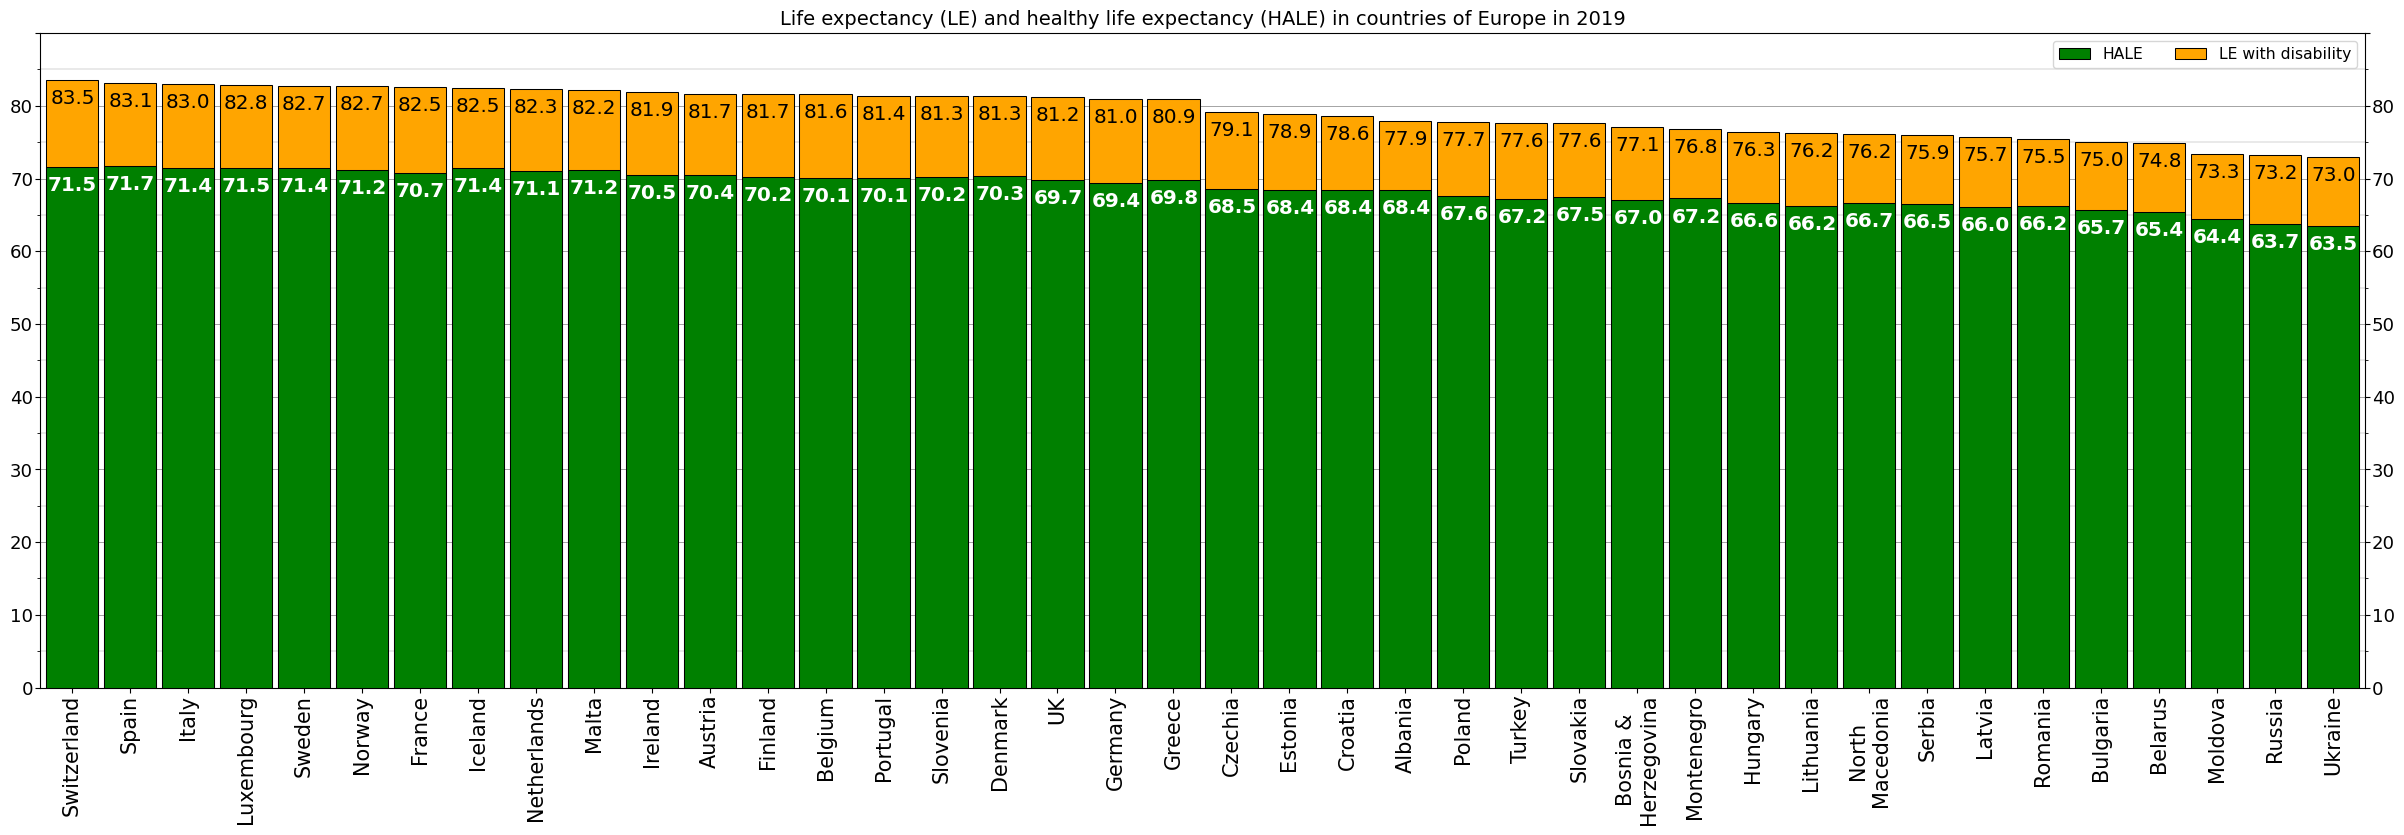

In [22]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(30, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of Europe in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в странах Европы в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Europe')

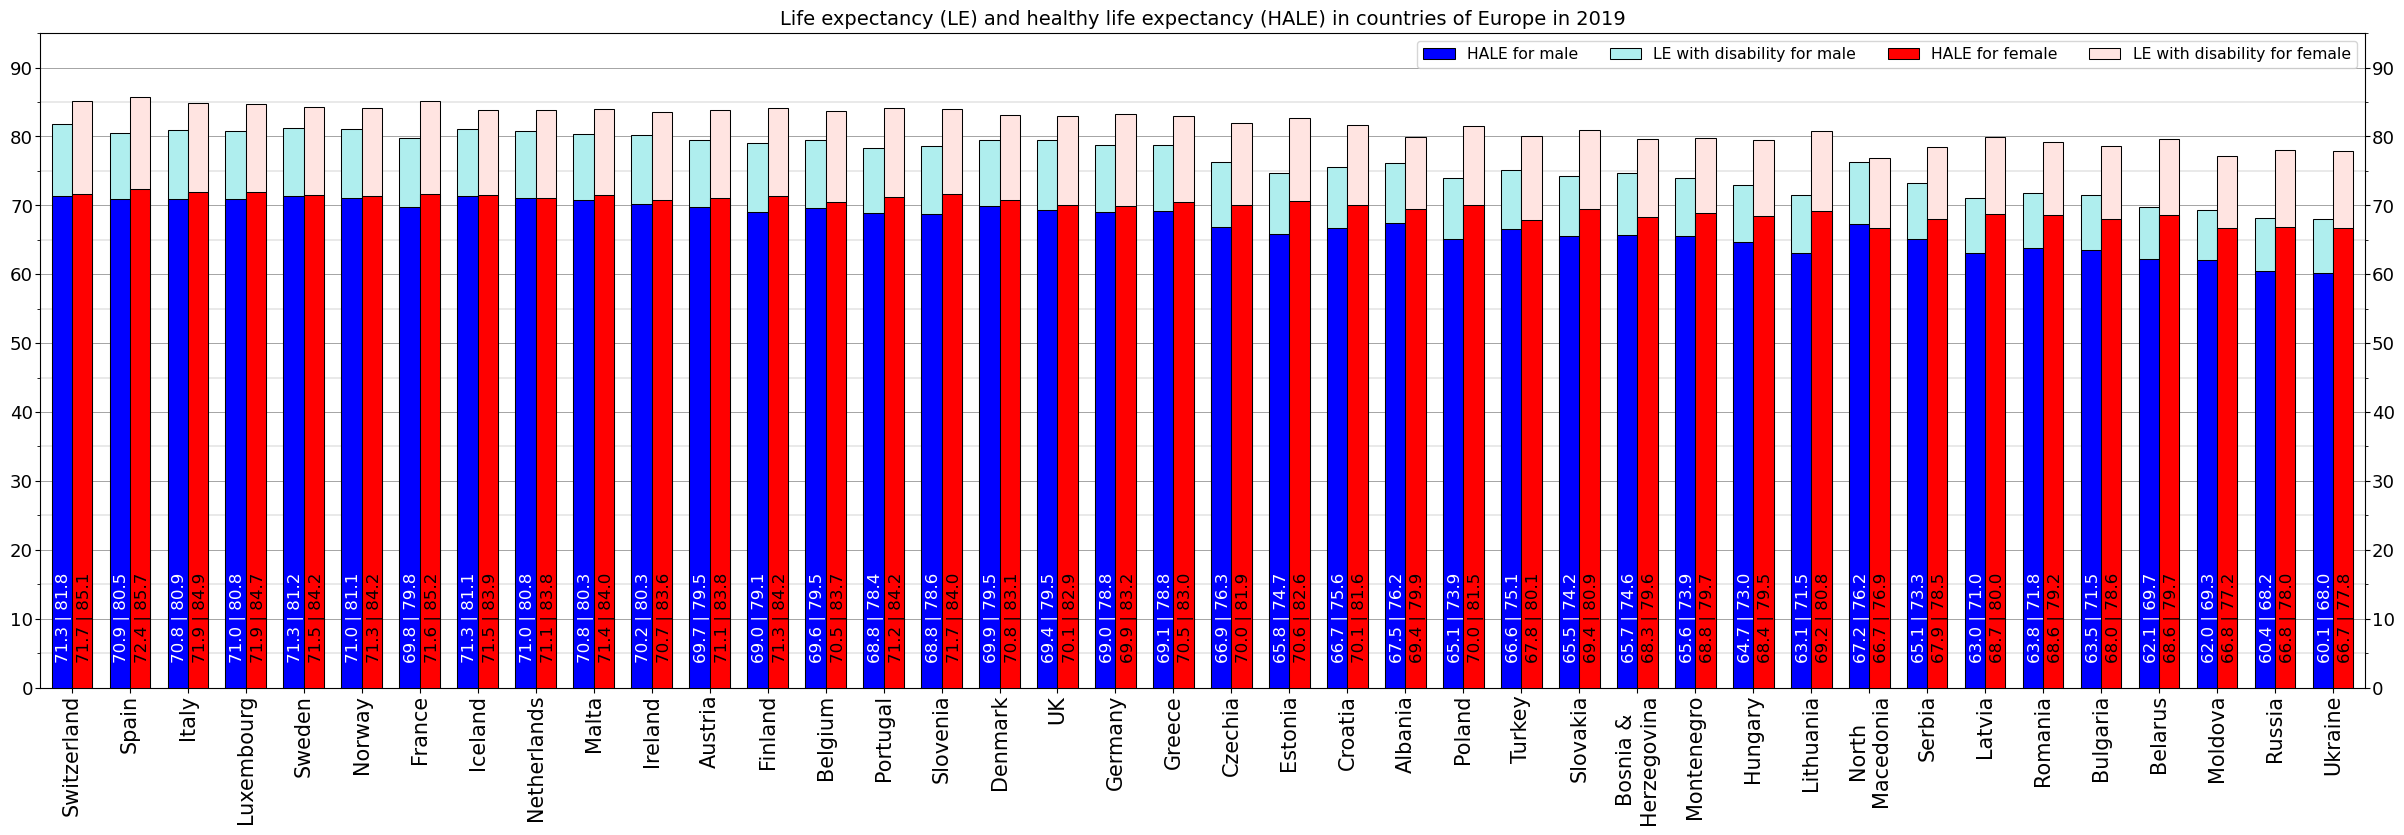

In [23]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Europe -sex')

<br />
<br />

**[European Union](https://en.wikipedia.org/wiki/European_Union#Member_states)**

In [25]:
ls_countries = ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland',
                'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
                'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'UK']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Spain,83.14,80.54,85.66,5.12,71.69,70.90,72.42,1.52,86.23
Italy,82.99,80.94,84.91,3.97,71.43,70.85,71.92,1.07,86.07
Luxembourg,82.80,80.83,84.74,3.91,71.46,70.98,71.89,0.91,86.30
...,...,...,...,...,...,...,...,...,...
Latvia,75.68,71.05,79.97,8.92,66.02,63.05,68.74,5.69,87.24
Romania,75.46,71.78,79.23,7.45,66.18,63.77,68.64,4.87,87.70
Bulgaria,75.00,71.52,78.62,7.10,65.67,63.46,67.95,4.49,87.56


Number of items: 28


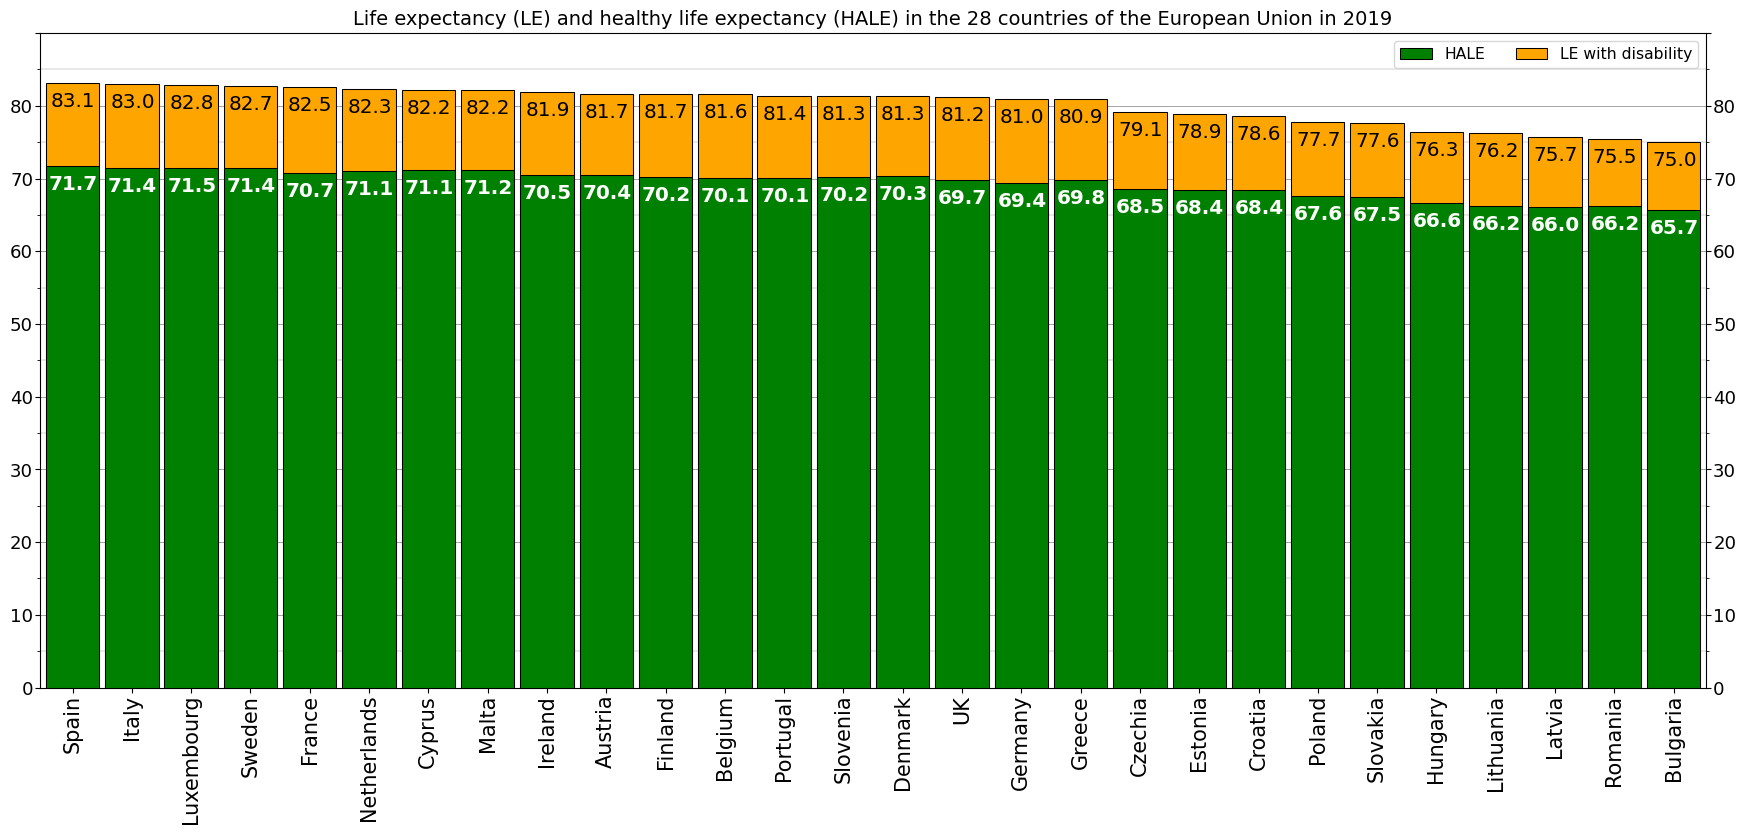

In [26]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(21.5, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in the 28 countries of the European Union in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в 28 странах Еврейского Союза в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -European Union')

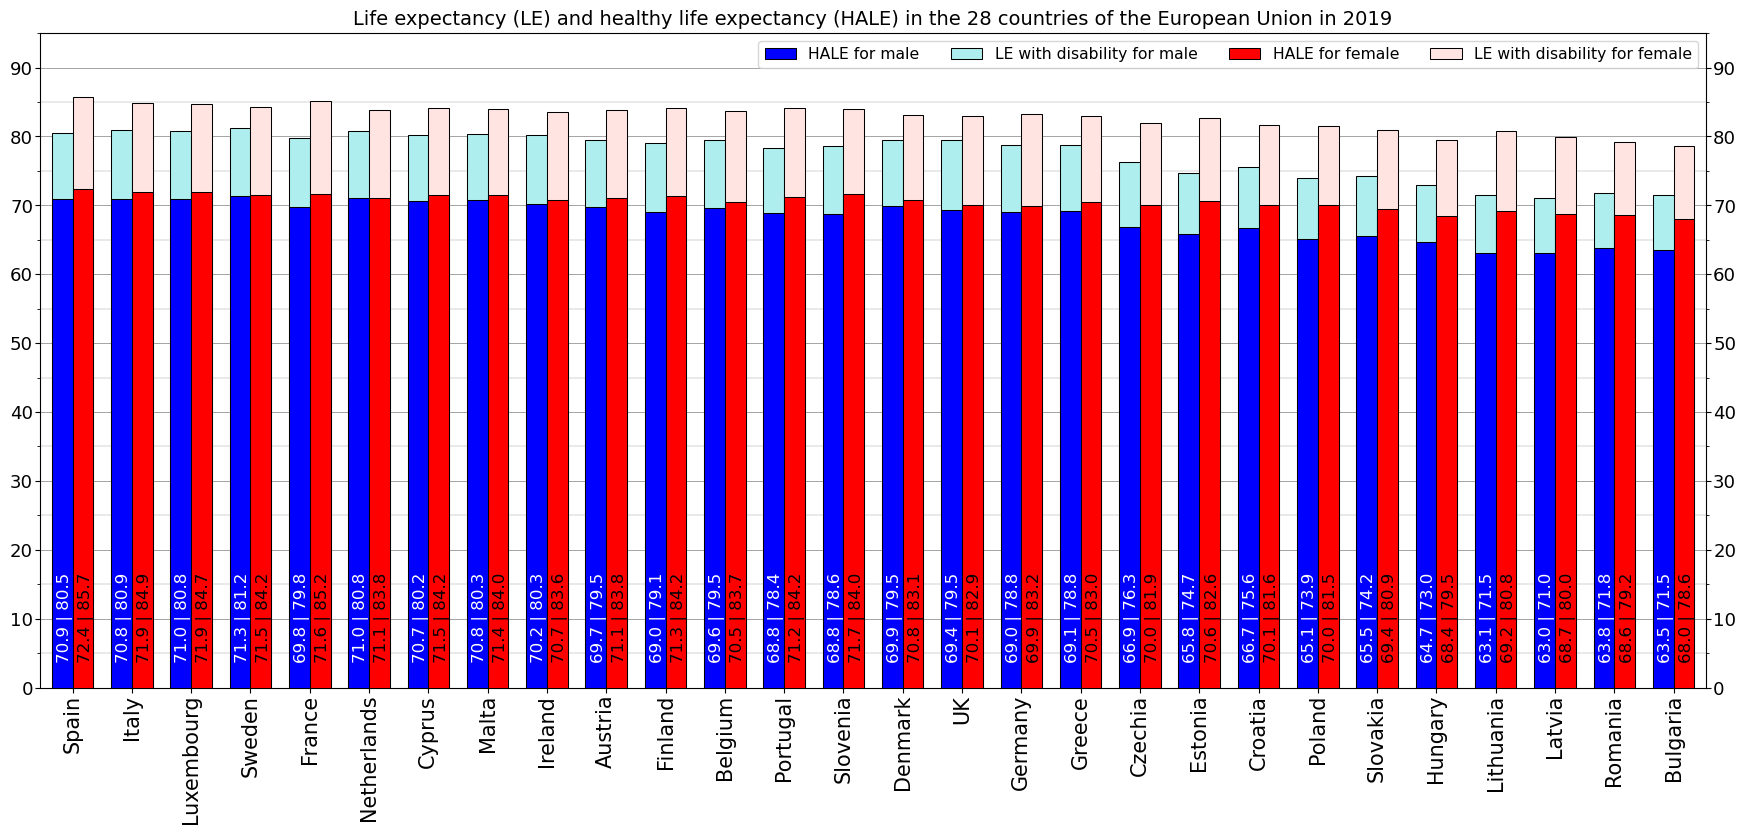

In [27]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -European Union -sex')

<br />
<br />

**Asia**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_Asian_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_Asian_countries_by_population#Table),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_Asia#Sovereign_states)

In [29]:
ls_countries = ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bangladesh', 'Cambodia', 'China', 'Georgia', 'India',
                'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan',
                'Lebanon', 'Malaysia', 'Myanmar', 'Nepal', 'North Korea', 'Oman', 'Pakistan', 'Philippines',
                'Qatar', 'Russia', 'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Tajikistan',
                'Thailand', 'Turkey', 'Turkmenistan', 'UAE', 'Uzbekistan', 'Vietnam', 'Yemen']
               # ['Mongolia', 'Bahrain', 'Timor-Leste', 'Cyprus']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Japan,84.47,81.70,87.15,5.45,73.58,72.09,75.01,2.92,87.11
Singapore,83.90,81.81,85.98,4.17,73.80,72.66,74.89,2.23,87.96
South Korea,83.69,80.56,86.56,6.00,72.50,70.62,74.19,3.57,86.63
...,...,...,...,...,...,...,...,...,...
Pakistan,67.03,66.30,67.79,1.49,57.80,58.12,57.50,-0.62,86.23
Yemen,66.90,63.95,70.01,6.06,57.36,56.40,58.35,1.95,85.74
Afghanistan,61.22,60.04,62.55,2.51,52.31,51.87,52.84,0.97,85.45


Number of items: 40


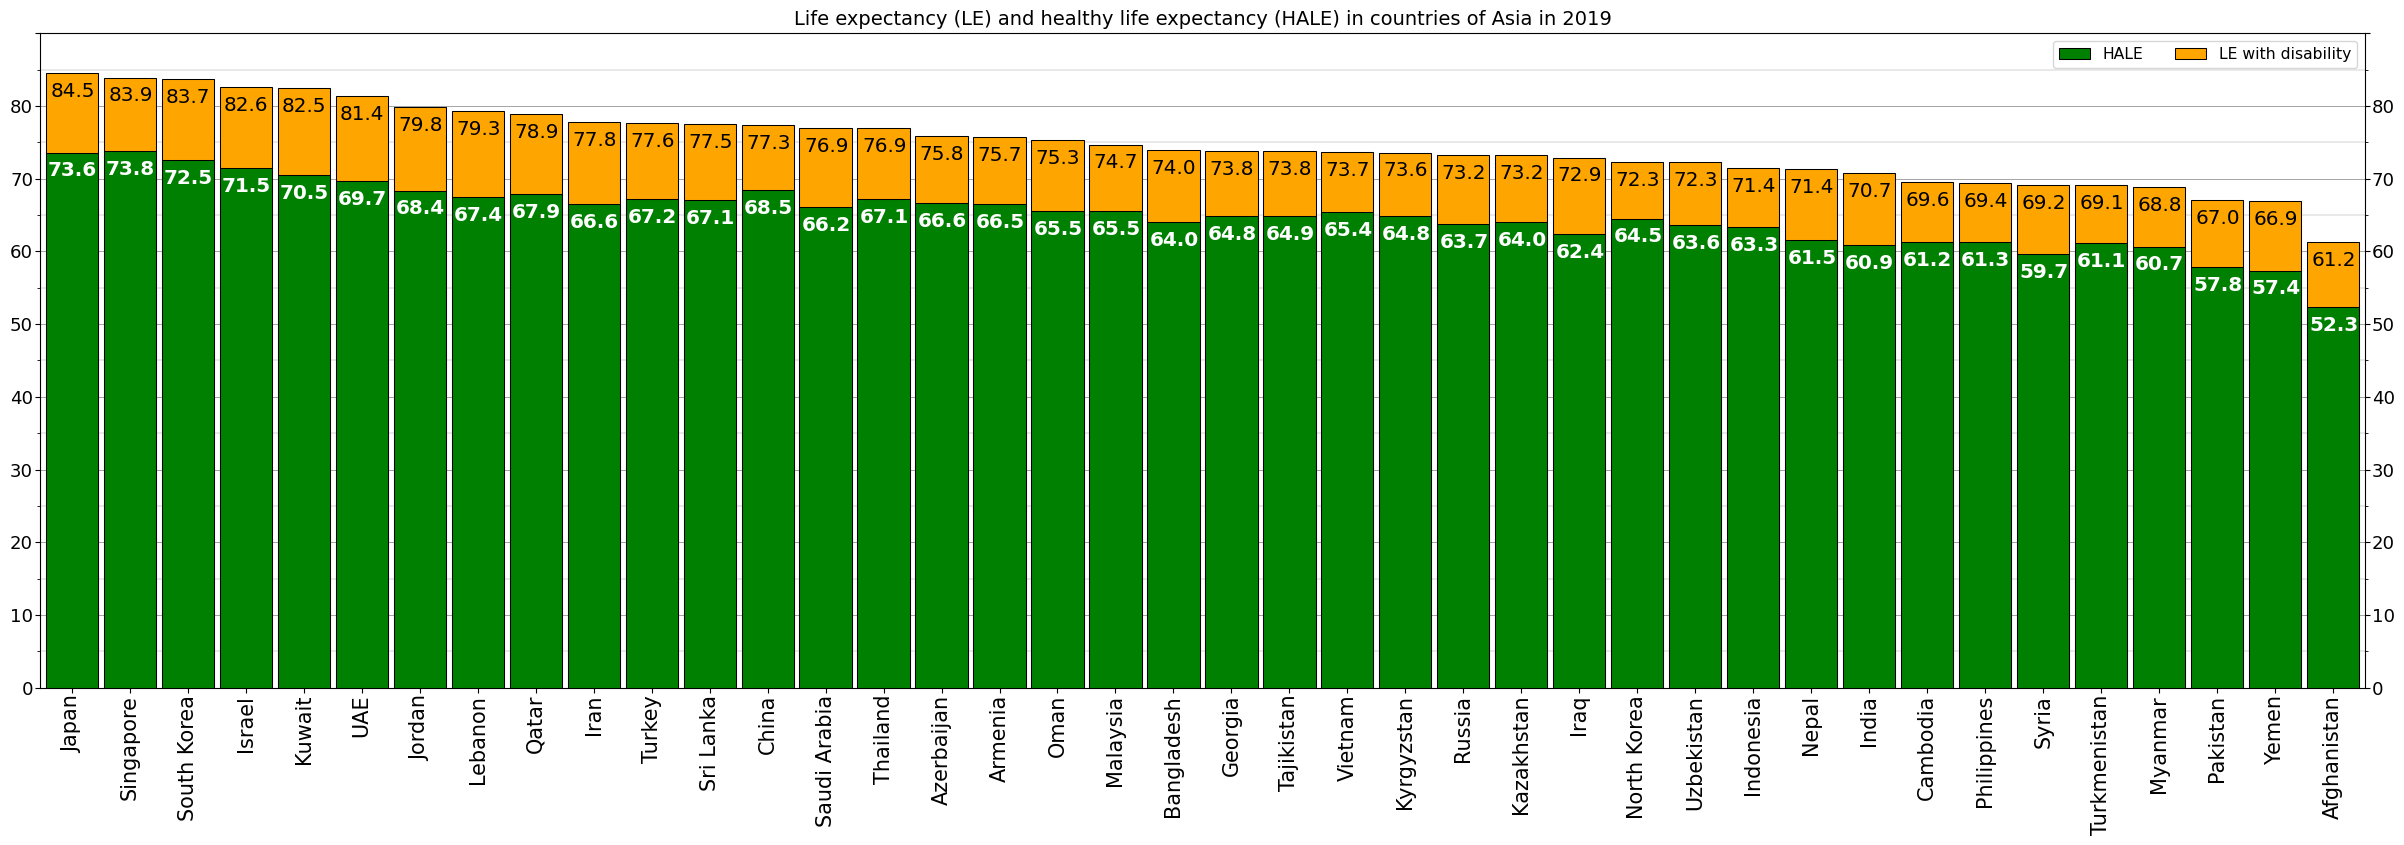

In [30]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(30, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of Asia in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в странах Азии в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Asia')

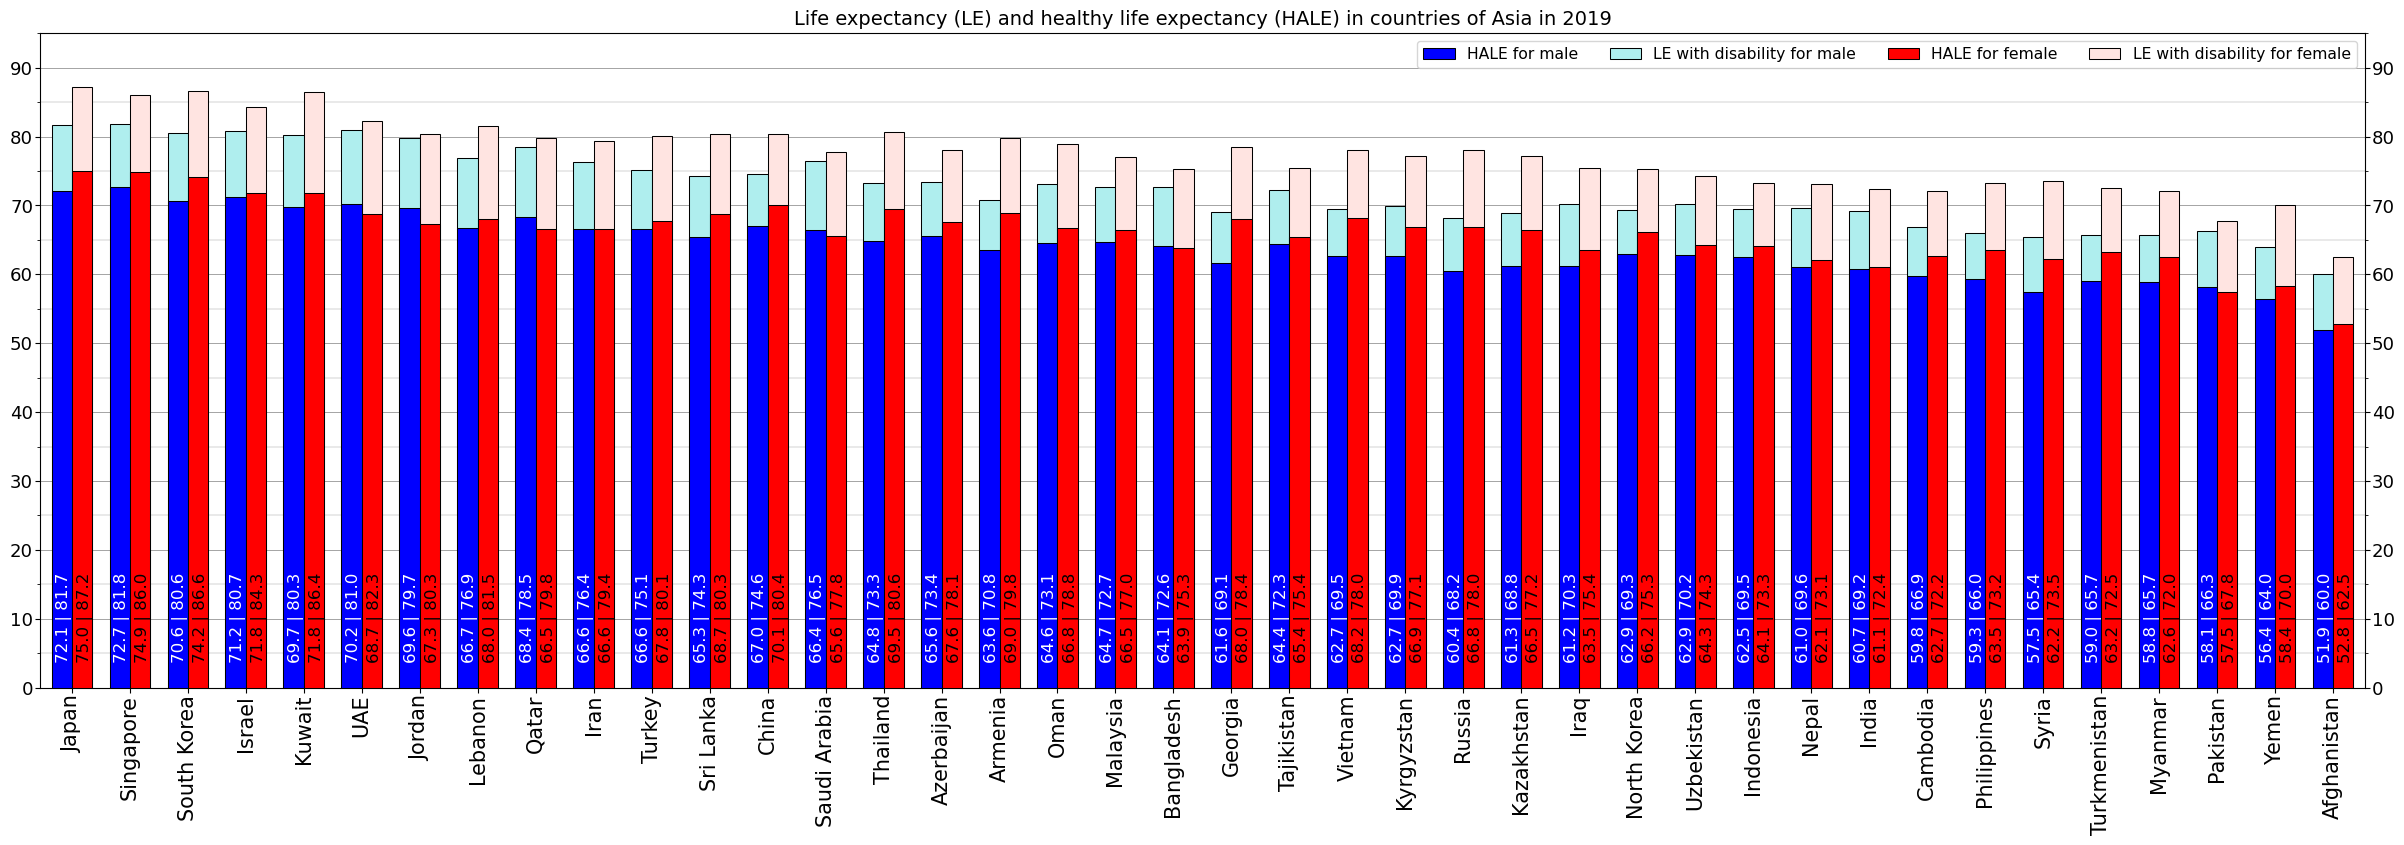

In [31]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Asia -sex')

<br />
<br />

**Asia**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_Asian_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_Asian_countries_by_population#Table),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_Asia#Sovereign_states)<br />
**Oceania**:
[list by population](https://en.wikipedia.org/wiki/List_of_Oceanian_countries_by_population#Table),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_Oceania#Sovereign_states)

In [33]:
ls_countries = ['Afghanistan', 'Armenia', 'Azerbaijan', 'Bangladesh', 'Cambodia', 'China', 'Georgia', 'India',
                'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kyrgyzstan', 'Laos',
                'Malaysia', 'Myanmar', 'Nepal', 'North Korea', 'Pakistan', 'Philippines', 'Russia',
                'Saudi Arabia', 'Singapore', 'South Korea', 'Sri Lanka', 'Syria', 'Tajikistan', 'Thailand',
                'Turkey', 'Turkmenistan', 'UAE', 'Uzbekistan', 'Vietnam', 'Yemen'] +\
               ['Australia', 'New Zealand', 'Papua\nNew Guinea']
               # ['Lebanon', 'Oman', 'Kuwait', 'Mongolia', 'Qatar', 'Bahrain', 'Timor-Leste', 'Cyprus']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Japan,84.47,81.70,87.15,5.45,73.58,72.09,75.01,2.92,87.11
Singapore,83.90,81.81,85.98,4.17,73.80,72.66,74.89,2.23,87.96
South Korea,83.69,80.56,86.56,6.00,72.50,70.62,74.19,3.57,86.63
...,...,...,...,...,...,...,...,...,...
Yemen,66.90,63.95,70.01,6.06,57.36,56.40,58.35,1.95,85.74
Papua\nNew Guinea,66.67,65.57,67.92,2.35,58.47,58.09,58.92,0.83,87.70
Afghanistan,61.22,60.04,62.55,2.51,52.31,51.87,52.84,0.97,85.45


Number of items: 40


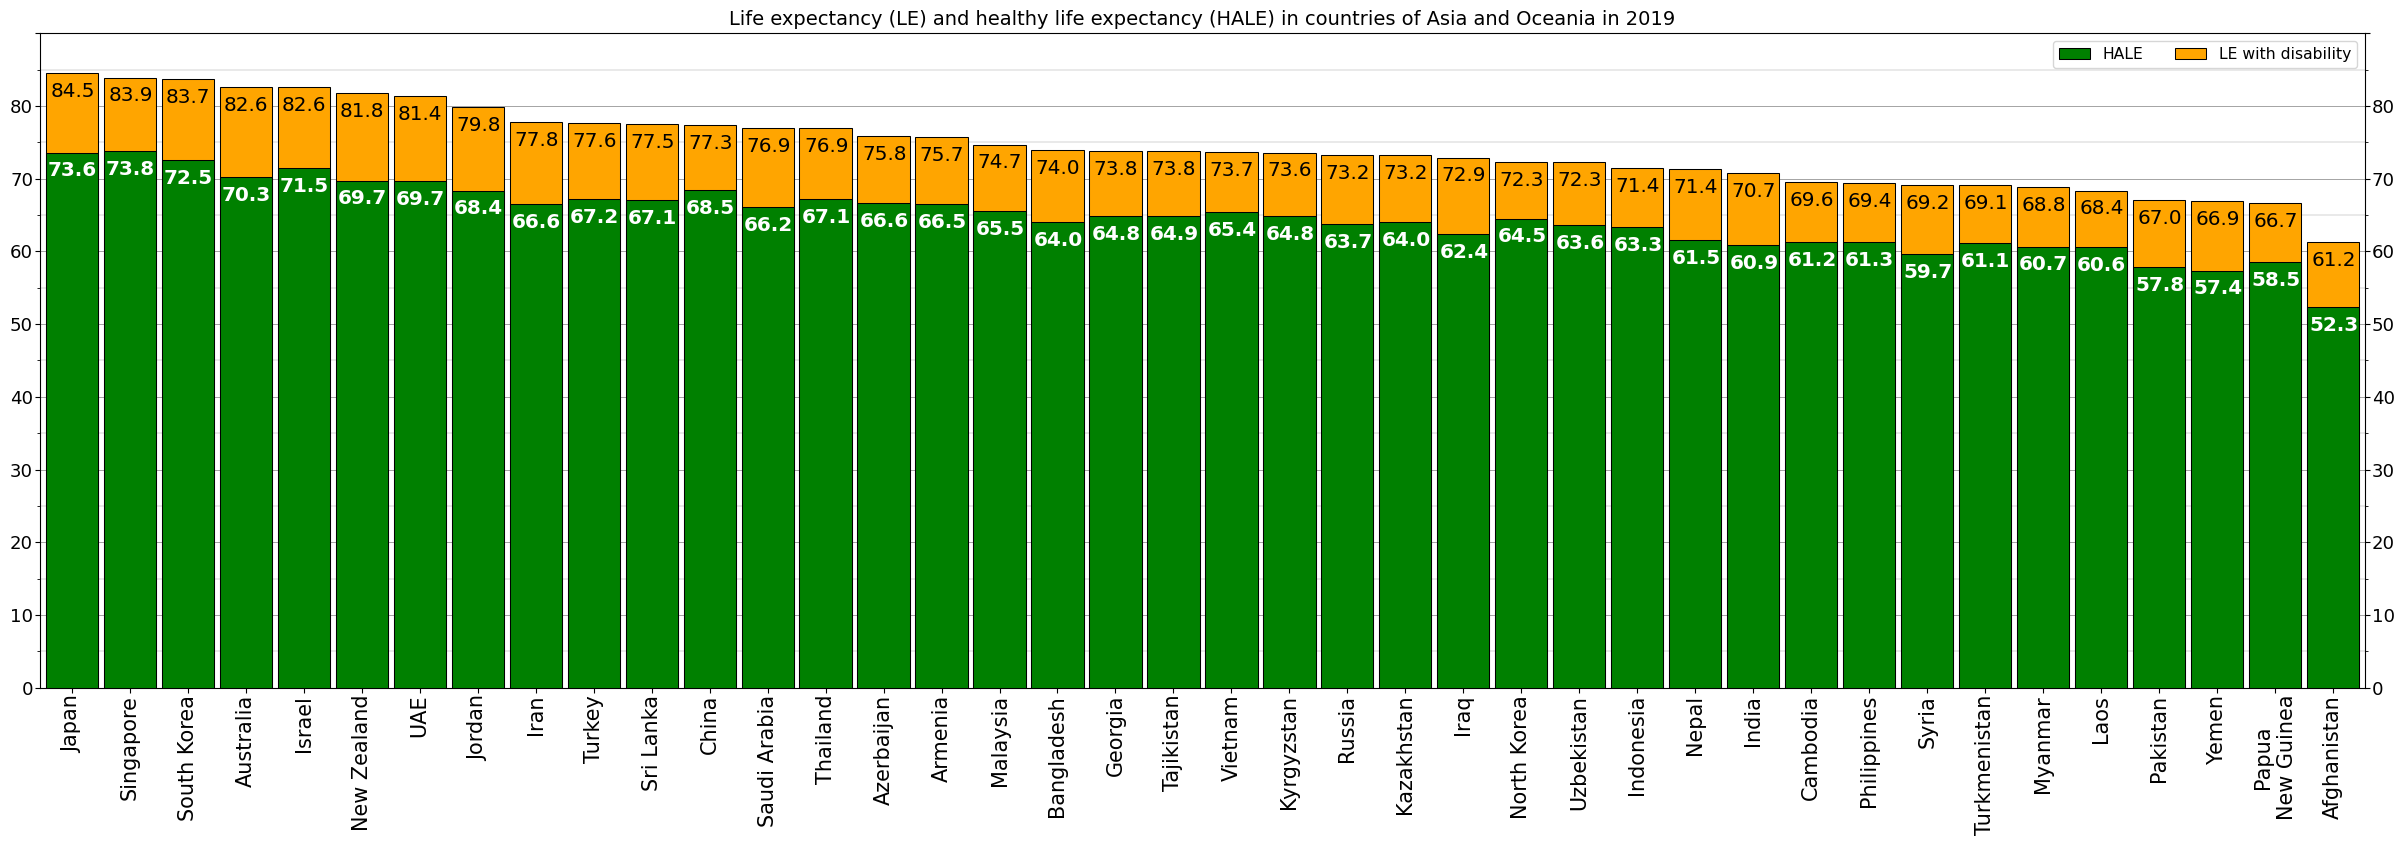

In [34]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(30, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of Asia and Oceania in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в странах Азии и Океании в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Asia and Oceania')

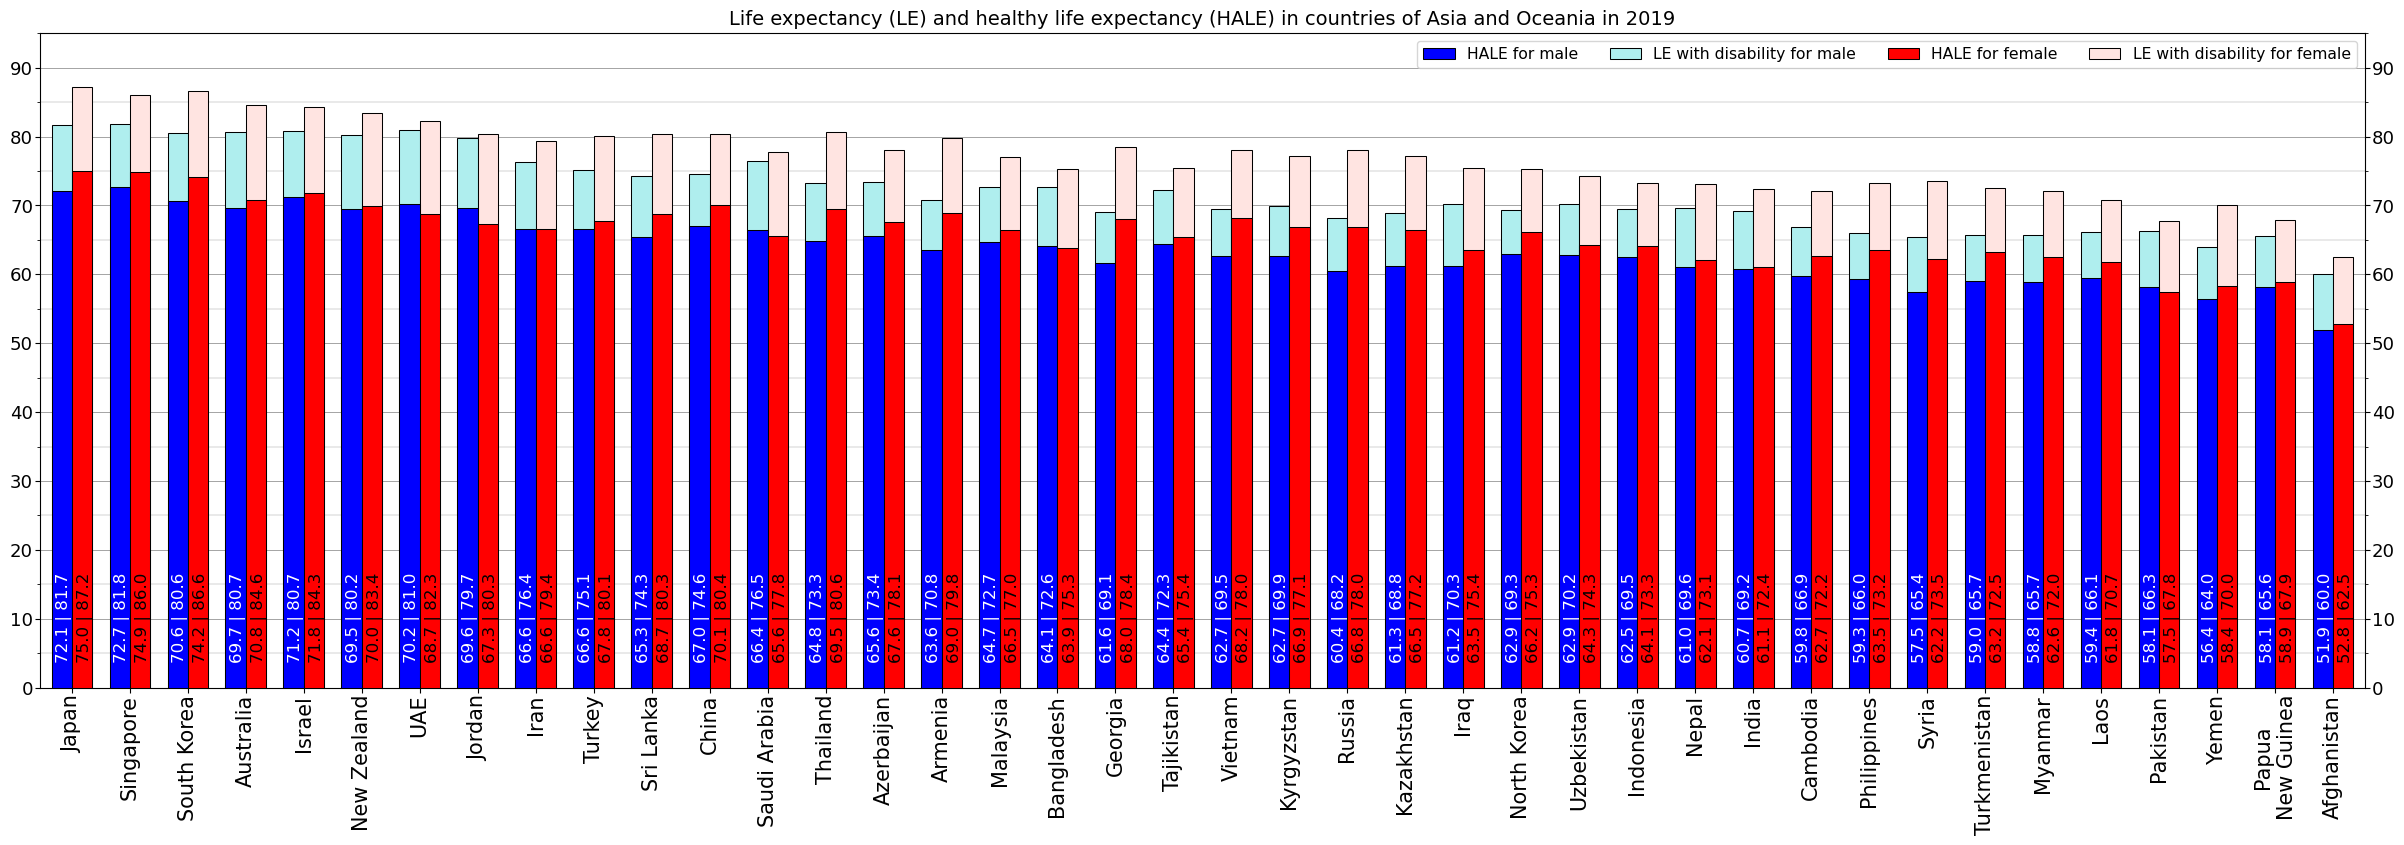

In [35]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Asia and Oceania -sex')

<br />
<br />

**South America**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_South_American_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_South_American_countries_by_population),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_South_America#Sovereign_states)<br />
**North America**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_North_American_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_North_American_countries_by_population),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_North_America#Sovereign_states)

In [37]:
ls_countries = ['Argentina', 'Bahamas', 'Barbados', 'Belize', 'Bolivia', 'Brazil', 'Canada', 'Chile',
                'Colombia', 'Costa Rica', 'Cuba', 'Dominican\nRepublic', 'Ecuador', 'El Salvador',
                'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua', 'Panama',
                'Paraguay', 'Peru', 'Puerto Rico', 'Saint Lucia', 'Suriname', 'Trinidad &\nTobago',
                'USA', 'Uruguay', 'Venezuela']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Canada,82.02,80.12,83.90,3.78,70.30,69.66,70.91,1.25,85.71
Chile,81.03,78.66,83.34,4.68,69.37,68.65,70.05,1.40,85.61
Puerto Rico,80.50,76.86,84.04,7.18,69.44,67.20,71.62,4.42,86.26
...,...,...,...,...,...,...,...,...,...
Bahamas,70.74,68.08,73.26,5.18,61.78,60.38,63.11,2.73,87.33
Guyana,68.73,65.58,71.99,6.41,59.14,57.25,61.11,3.86,86.05
Haiti,63.66,63.18,64.16,0.98,55.00,55.56,54.47,-1.09,86.40


Number of items: 31


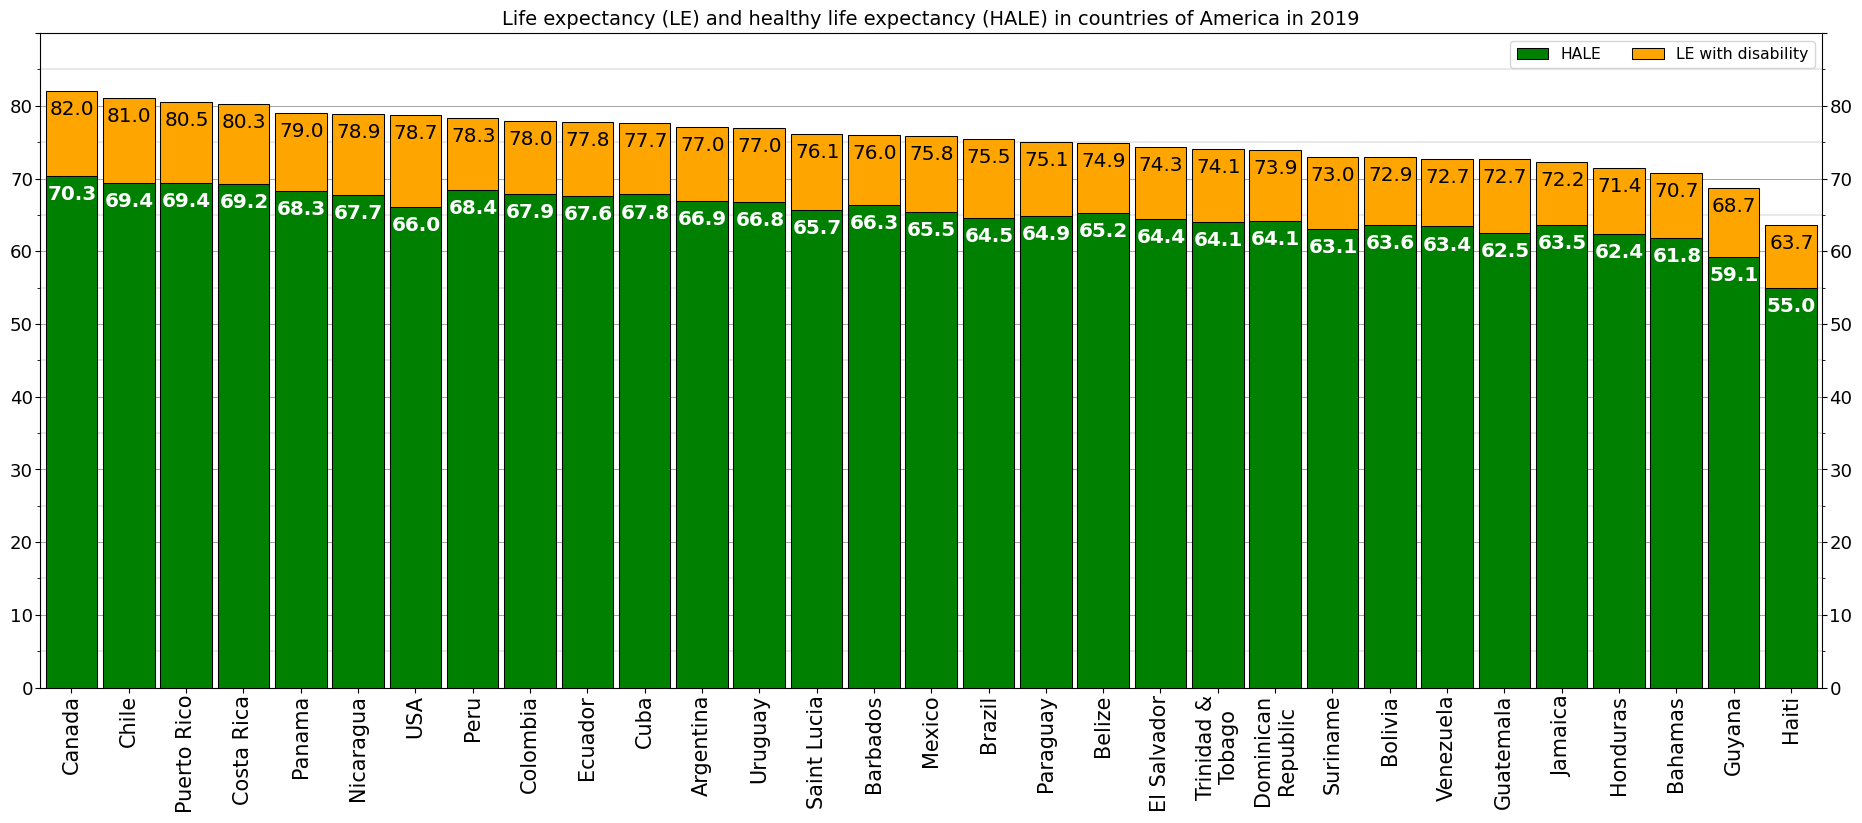

In [38]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(23, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of America in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в странах Америки в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -America')

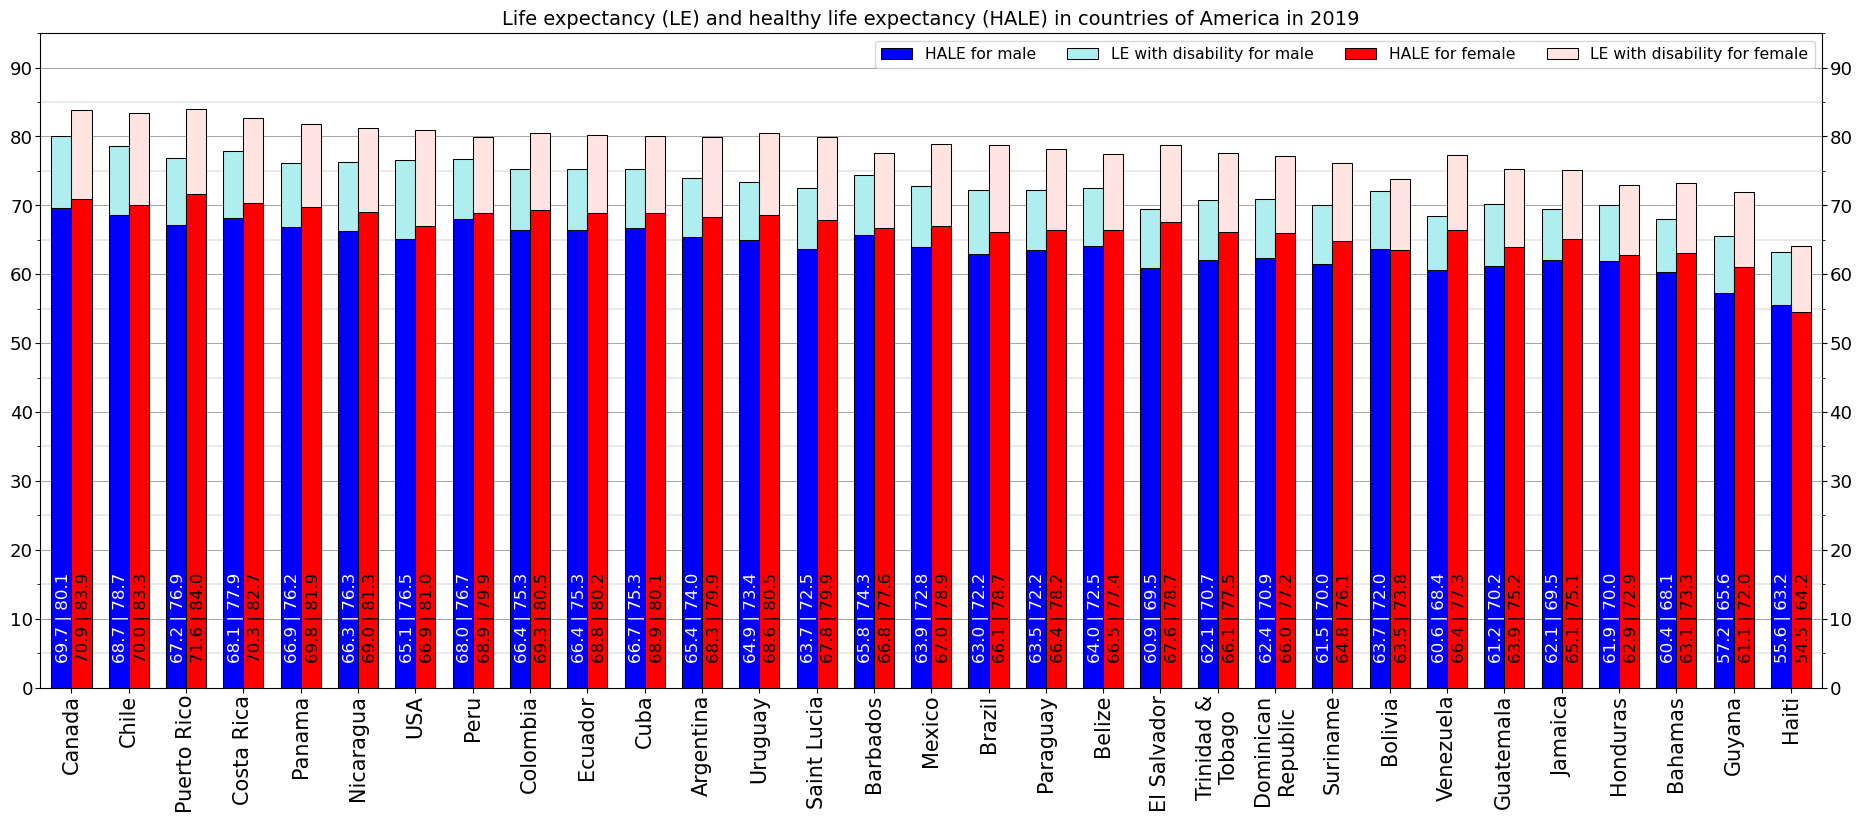

In [39]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -America -sex')

<br />
<br />

**Latin America**:
[list by life expectancy](https://en.wikipedia.org/wiki/Latin_America#Life_expectancy),
[list of states](https://en.wikipedia.org/wiki/Latin_America#Subregions_and_countries)

In [41]:
ls_countries = ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Costa Rica', 'Cuba', 'Dominican\nRepublic',
                'Ecuador', 'El Salvador', 'Guatemala', 'Haiti', 'Honduras', 'Mexico', 'Nicaragua', 'Panama',
                'Paraguay', 'Peru', 'Puerto Rico', 'Uruguay', 'Venezuela']
# in the database there are no data for Guadeloupe, Martinique, French Guiana, Saint Martin, Saint Barthélemy

# Biggest American countries that are not Latin: 'USA', 'Canada', 'Jamaica', 'Trinidad & Tobago', 'Bahamas',
#                                                'Belize', 'Barbados', 'Saint Lucia', 'Guyana', 'Suriname'

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Chile,81.03,78.66,83.34,4.68,69.37,68.65,70.05,1.40,85.61
Puerto Rico,80.50,76.86,84.04,7.18,69.44,67.20,71.62,4.42,86.26
Costa Rica,80.30,77.93,82.71,4.78,69.21,68.09,70.35,2.26,86.19
...,...,...,...,...,...,...,...,...,...
Venezuela,72.71,68.38,77.35,8.97,63.40,60.57,66.43,5.86,87.20
Honduras,71.44,69.99,72.90,2.91,62.35,61.85,62.85,1.00,87.28
Haiti,63.66,63.18,64.16,0.98,55.00,55.56,54.47,-1.09,86.40


In [42]:
# for country in ls_countries:
#     print(f"Life expectancy charts for {country}")

Number of items: 21


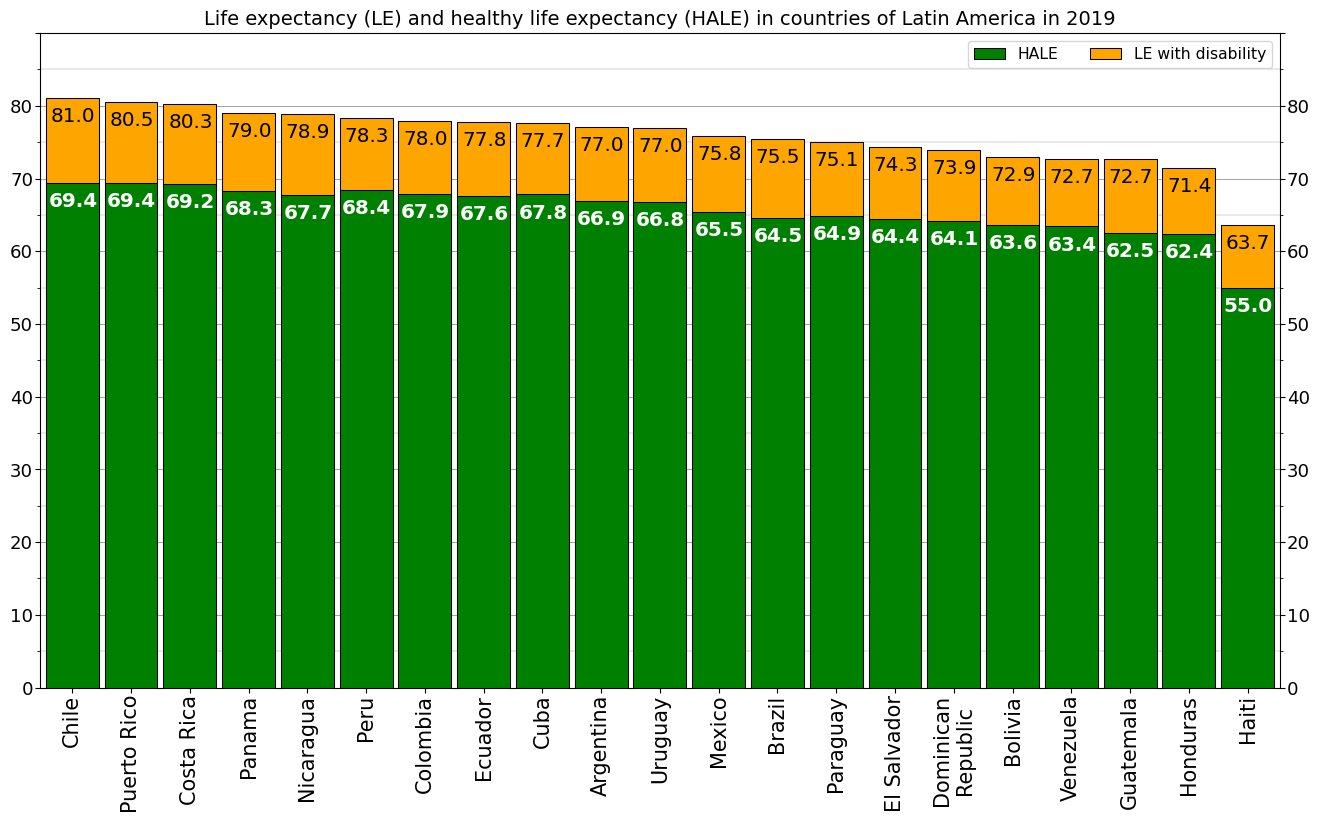

In [43]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(16, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of Latin America in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ)\nв странах Латинской Америки в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Latin America')

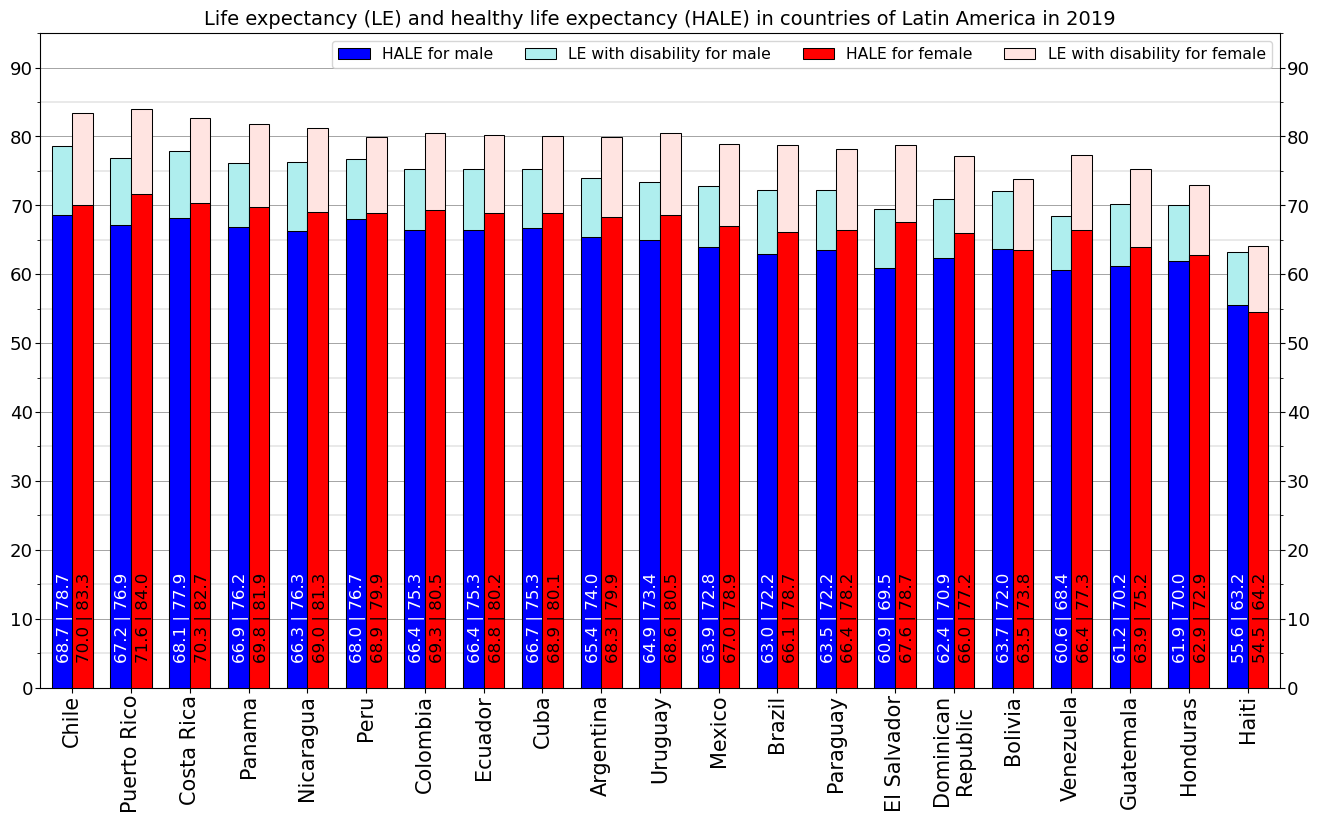

In [44]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Latin America -sex')

<br />
<br />

**Africa**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_African_countries_by_life_expectancy),
[list by population](https://en.wikipedia.org/wiki/List_of_African_countries_by_population#Table),
[list of states](https://en.wikipedia.org/wiki/List_of_sovereign_states_and_dependent_territories_in_Africa#Sovereign_states)

In [46]:
ls_countries = ['Algeria', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'CAR', 'Cameroon', 'Chad', "Côte d'Ivoire",
                'DR Congo', 'Egypt', 'Eritrea', 'Ethiopia', 'Ghana', 'Guinea', 'Kenya', 'Liberia', 'Libya',
                'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Morocco', 'Mozambique', 'Niger', 'Nigeria',
                'Republic of\nCongo', 'Rwanda', 'Senegal', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan',
                'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']
               # ['Botswana']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Tunisia,77.51,75.09,79.99,4.90,66.68,66.03,67.38,1.35,86.03
Algeria,76.55,76.24,77.08,0.84,66.14,67.04,65.34,-1.70,86.40
Morocco,73.75,72.85,74.64,1.79,63.60,64.13,63.04,-1.09,86.24
...,...,...,...,...,...,...,...,...,...
Mozambique,58.51,55.39,61.67,6.28,50.65,49.27,52.06,2.79,86.57
Somalia,55.21,52.87,57.75,4.88,48.65,47.28,50.14,2.86,88.12
CAR,52.93,50.31,55.89,5.58,45.97,44.41,47.75,3.34,86.85


Number of items: 40


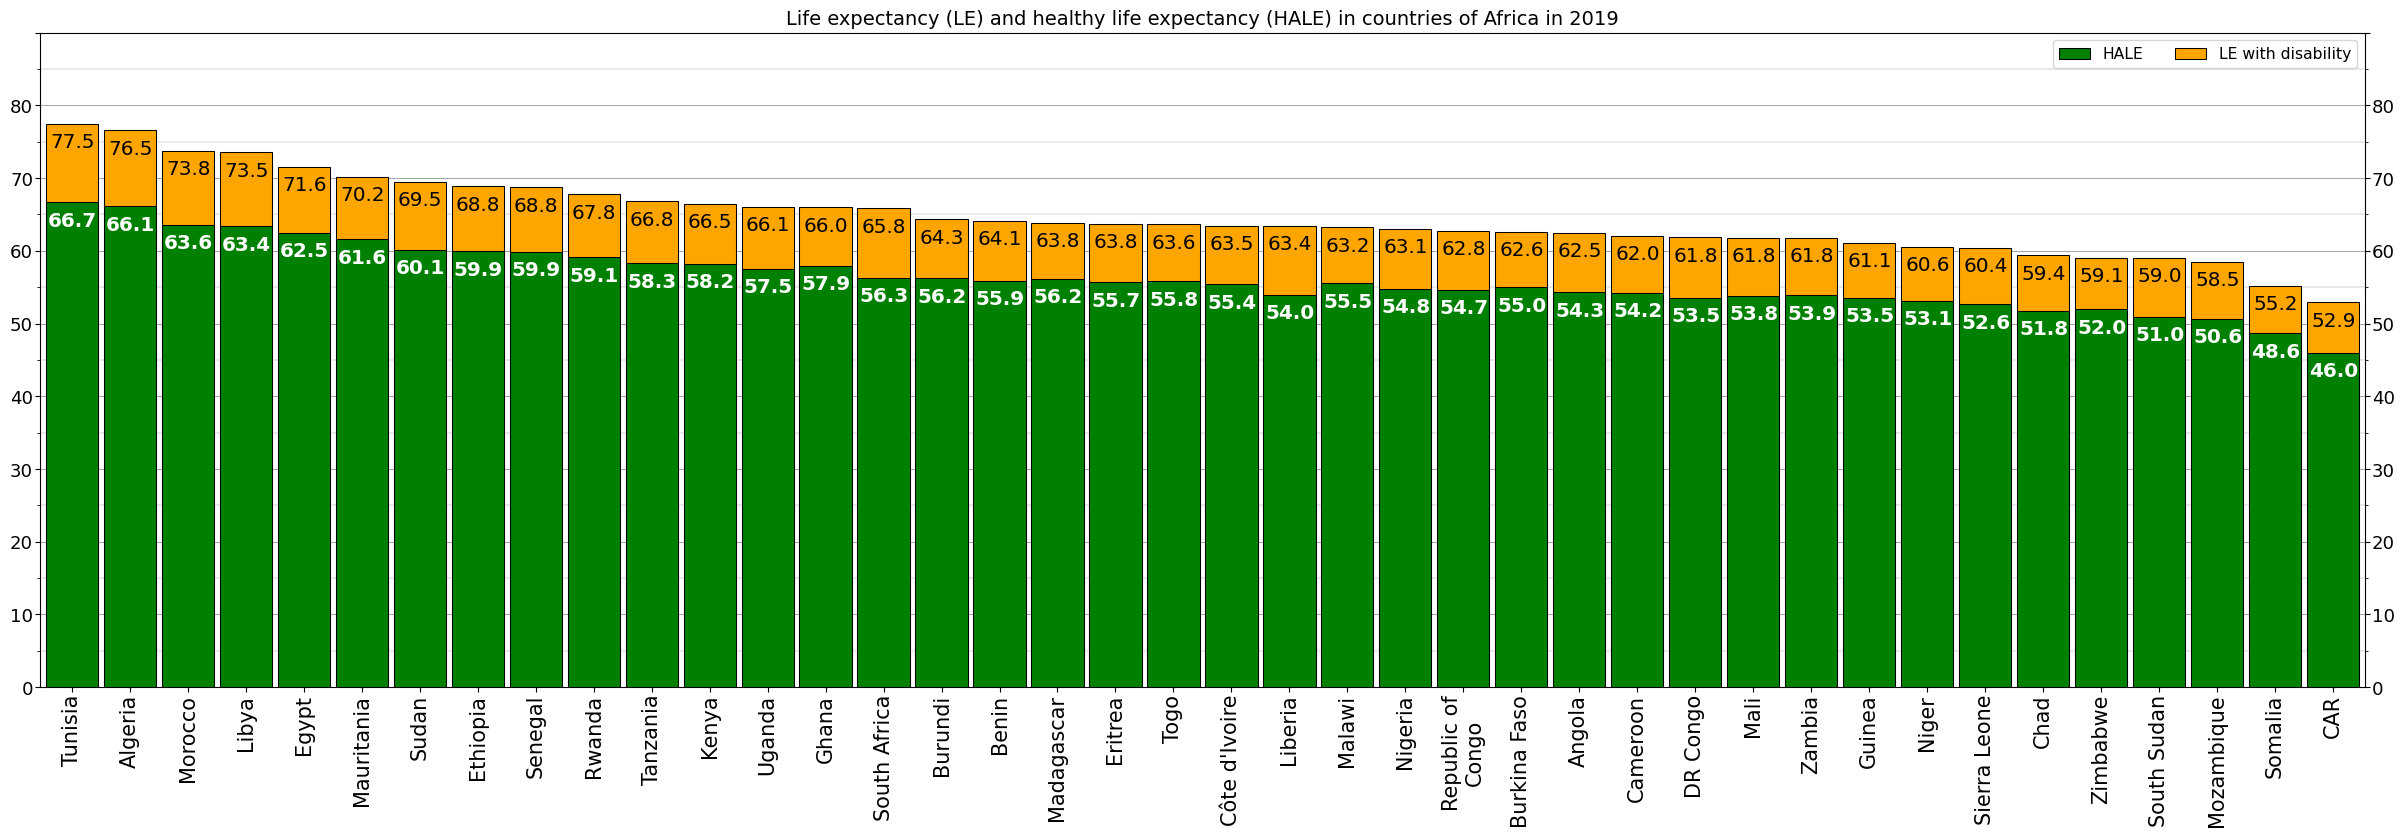

In [47]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(30, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of Africa in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ) в странах Африки в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -Africa')

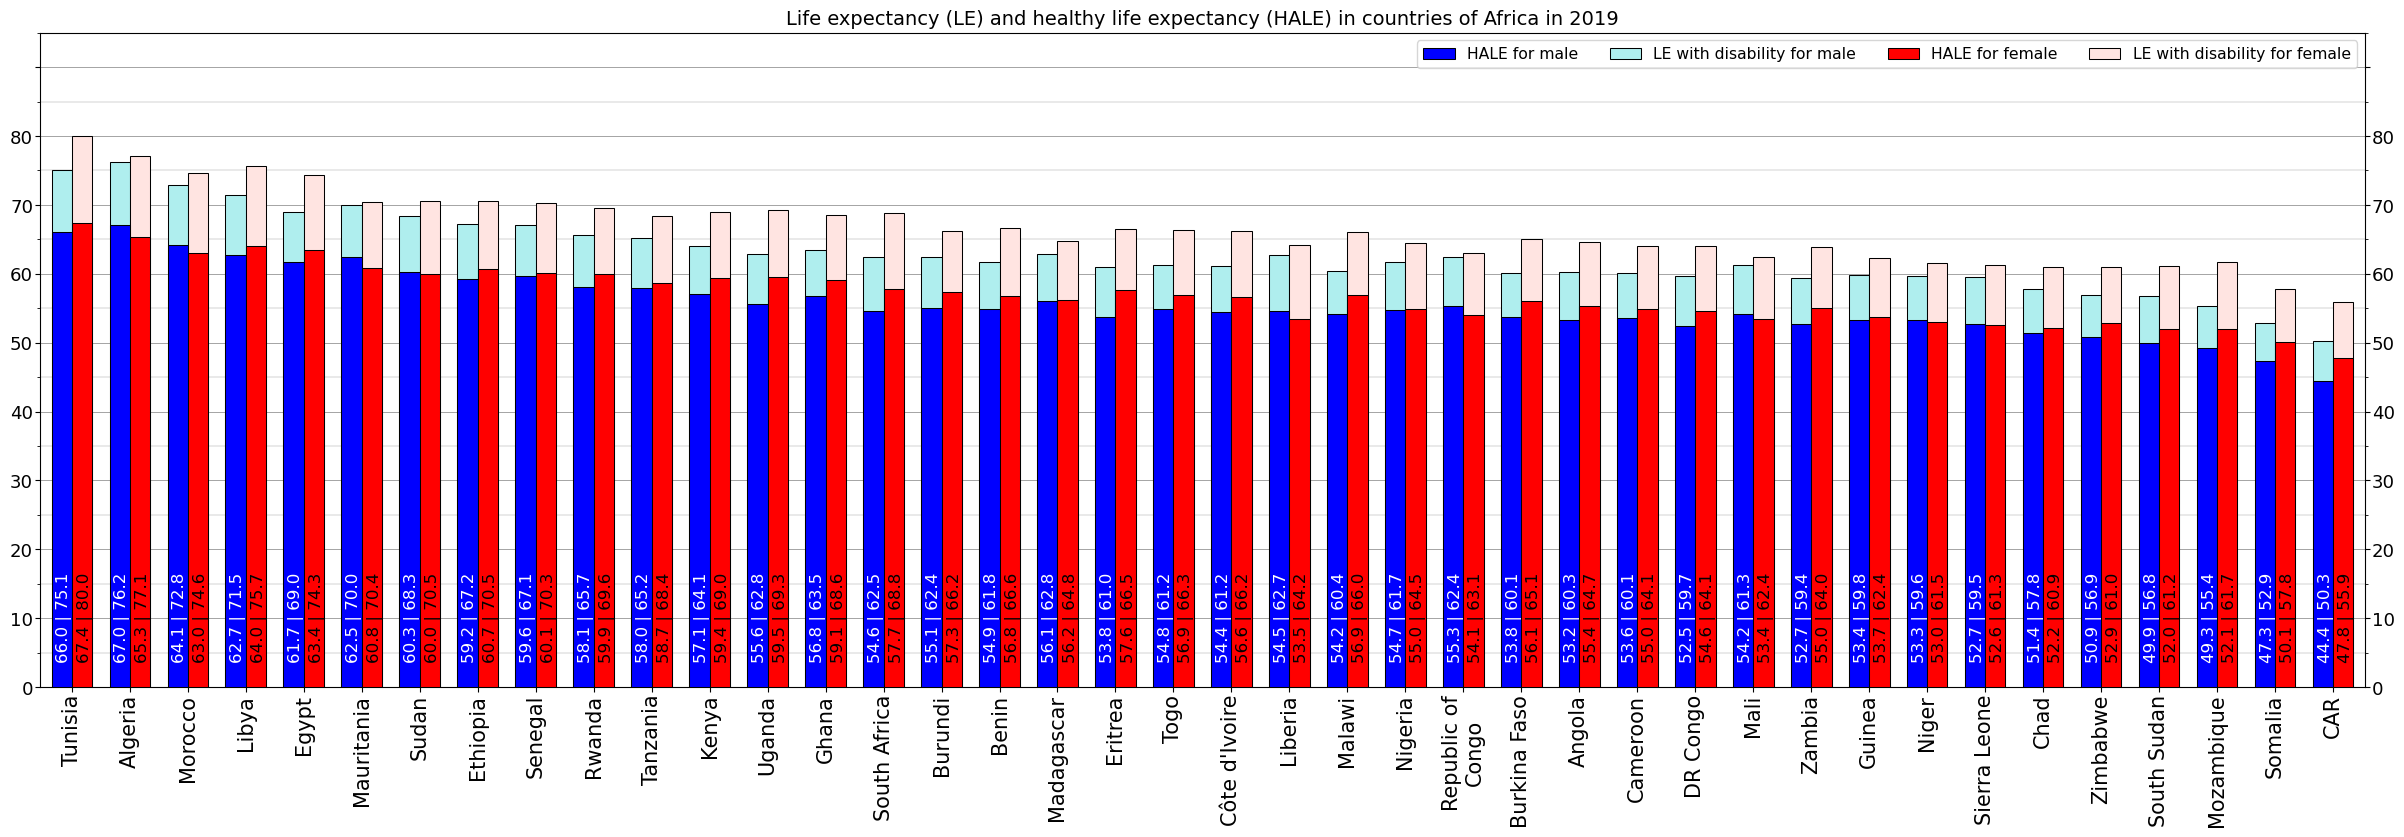

In [48]:
compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, hide_upper_label=True, file_name='Healthy life expectancy bar chart -Africa -sex')

<br />
<br />

[**CIS** (Commonwealth of Independent States)](https://en.wikipedia.org/wiki/Commonwealth_of_Independent_States#Membership)

In [50]:
ls_countries = ['Armenia', 'Azerbaijan', 'Belarus', 'Kazakhstan', 'Kyrgyzstan', 'Moldova',
                'Russia', 'Tajikistan', 'Turkmenistan', 'Uzbekistan']  # 'Ukraine', 'Georgia'

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Azerbaijan,75.80,73.38,78.09,4.71,66.62,65.57,67.63,2.06,87.89
Armenia,75.67,70.82,79.79,8.97,66.48,63.56,68.96,5.40,87.86
Belarus,74.82,69.73,79.66,9.93,65.44,62.14,68.56,6.42,87.46
Tajikistan,73.81,72.28,75.37,3.09,64.91,64.42,65.42,1.00,87.94
Kyrgyzstan,73.59,69.92,77.14,7.22,64.84,62.68,66.93,4.25,88.11
Moldova,73.32,69.32,77.17,7.85,64.43,62.01,66.75,4.74,87.88
Russia,73.22,68.17,78.00,9.83,63.72,60.41,66.84,6.43,87.03
Kazakhstan,73.20,68.84,77.20,8.36,63.97,61.26,66.45,5.19,87.39
Uzbekistan,72.27,70.15,74.28,4.13,63.62,62.85,64.32,1.47,88.03


Number of items: 10


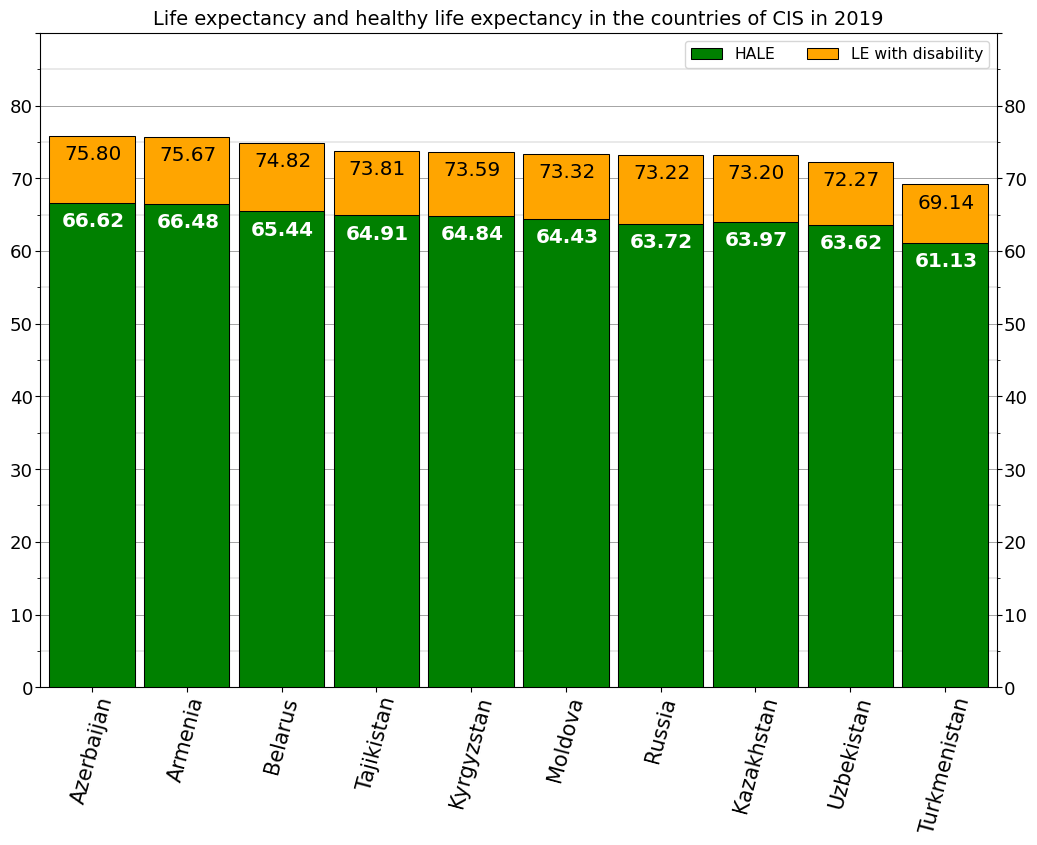

In [51]:
columns_sorting=['LE_o', 'HALE_o']
figure_size = (14, 8.5) if (LANG=='ru') else (12.35, 8.5)
title_en = 'Life expectancy and healthy life expectancy in the countries of CIS in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ)\nв странах СНГ в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -CIS',
                  label_rotation=75, value_precision=2)

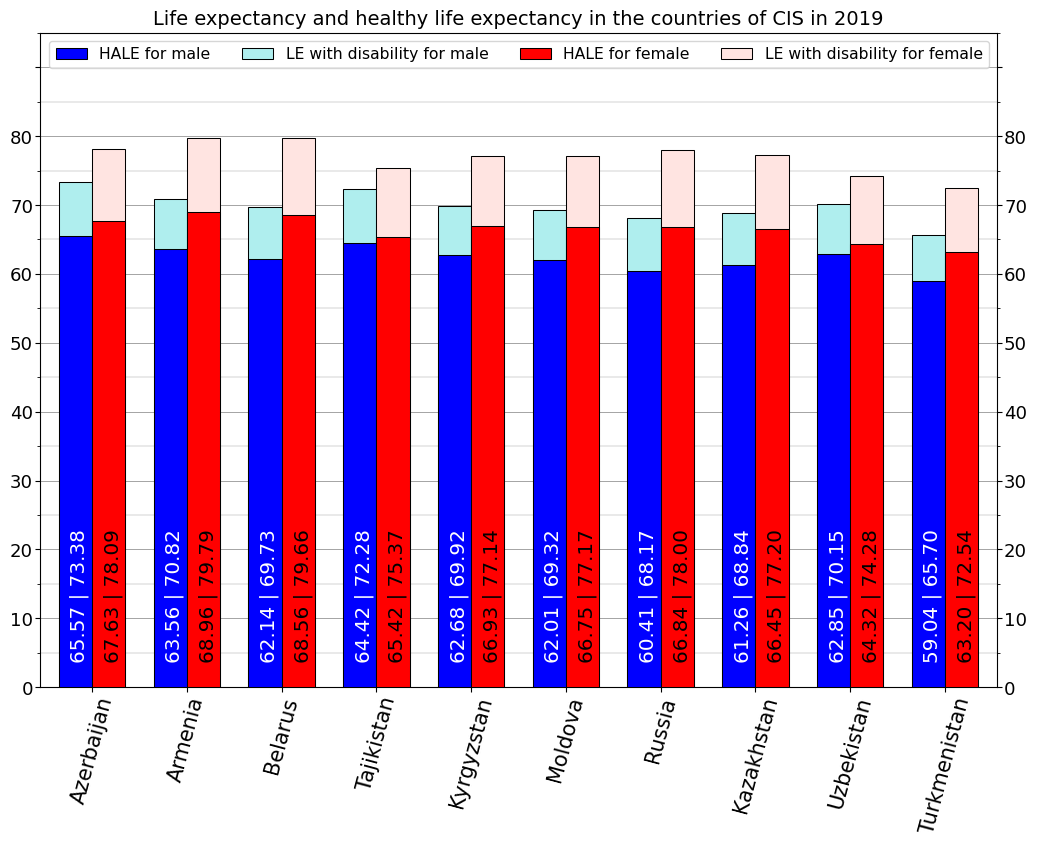

In [52]:
short_legend = (LANG=='ru')

compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, short_legend=short_legend, hide_upper_label=True,
                         destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -CIS -sex',
                         label_rotation=75, value_precision=2, size_text_on_chart='x-large')

<br />
<br />

[**Post-Soviet states**](https://en.wikipedia.org/wiki/Post-Soviet_states)

In [54]:
ls_countries = ['Armenia', 'Azerbaijan', 'Belarus', 'Estonia', 'Georgia', 'Kazakhstan', 'Kyrgyzstan', 'Latvia',
                'Lithuania', 'Moldova', 'Russia', 'Tajikistan', 'Turkmenistan', 'Ukraine', 'Uzbekistan']

df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Estonia,78.89,74.69,82.61,7.92,68.37,65.80,70.59,4.79,86.66
Lithuania,76.25,71.45,80.82,9.37,66.23,63.10,69.17,6.07,86.86
Azerbaijan,75.80,73.38,78.09,4.71,66.62,65.57,67.63,2.06,87.89
Latvia,75.68,71.05,79.97,8.92,66.02,63.05,68.74,5.69,87.24
Armenia,75.67,70.82,79.79,8.97,66.48,63.56,68.96,5.40,87.86
Belarus,74.82,69.73,79.66,9.93,65.44,62.14,68.56,6.42,87.46
Georgia,73.85,69.10,78.44,9.34,64.85,61.61,67.98,6.37,87.81
Tajikistan,73.81,72.28,75.37,3.09,64.91,64.42,65.42,1.00,87.94
Kyrgyzstan,73.59,69.92,77.14,7.22,64.84,62.68,66.93,4.25,88.11


Number of items: 15


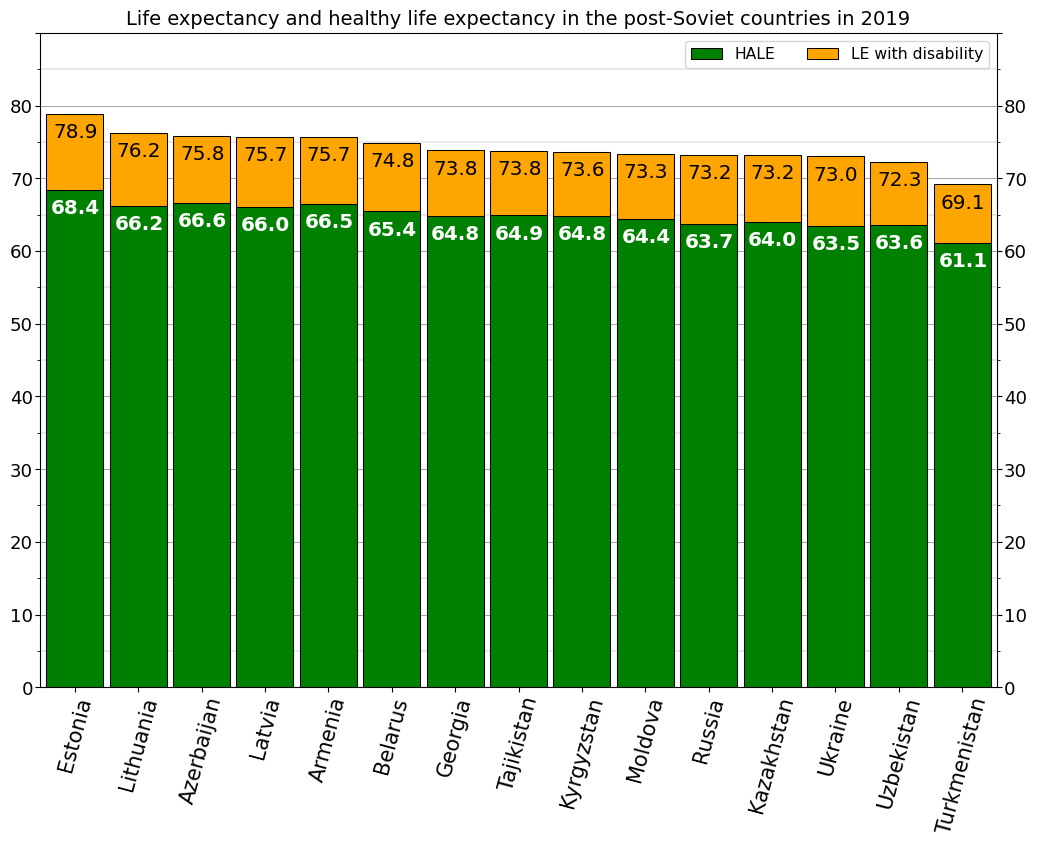

In [55]:
columns_sorting=['LE_o', 'HALE_o']
# figure_size = (12.35, 8.5)  # (14, 8.5)  if (LANG=='ru') else (12.35, 8.5)
figure_size = (14, 8.5) if (LANG=='ru') else (12.35, 8.5)
title_en = 'Life expectancy and healthy life expectancy in the post-Soviet countries in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ)\nв постсоветских странах в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru, destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -post-USSR',
                  label_rotation=75, value_precision=1)

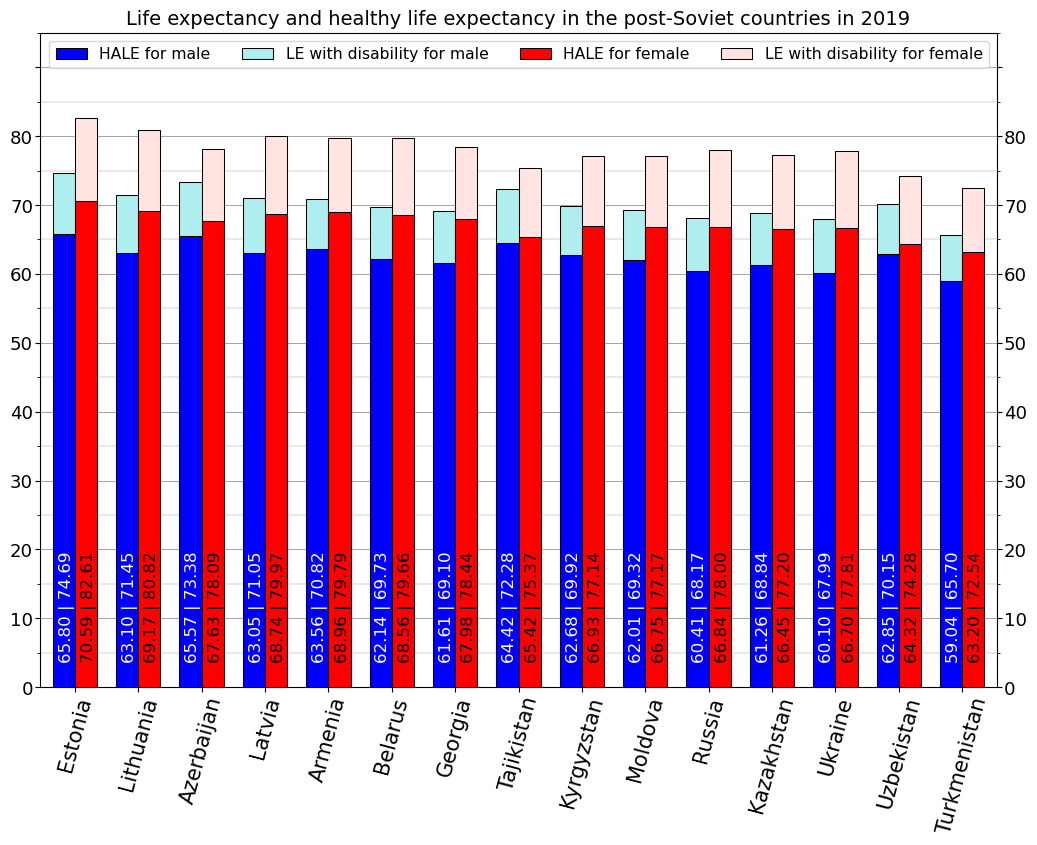

In [56]:
short_legend = (LANG=='ru')

compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, short_legend=short_legend, hide_upper_label=True,
                         destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -post-USSR -sex',
                         label_rotation=75, value_precision=2, size_text_on_chart='large')

<br />
<br />

**world regions**:
[list by life expectancy](https://en.wikipedia.org/wiki/List_of_world_regions_by_life_expectancy)

In [58]:
ls_countries = ['world', 'Africa', 'Americas', 'South-East\nAsia', 'Europe', 'Eastern\nMediterranean', 'Western\nPacific']
df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
Europe,78.10,74.99,81.13,6.14,67.58,66.07,69.04,2.97,86.53
Western\nPacific,77.49,74.51,80.70,6.19,68.35,66.70,70.13,3.43,88.20
Americas,77.07,74.42,79.76,5.34,65.76,64.51,67.01,2.50,85.33
world,73.12,70.61,75.70,5.09,63.45,62.33,64.59,2.26,86.78
South-East\nAsia,71.37,69.61,73.23,3.62,61.82,61.38,62.28,0.90,86.62
Eastern\nMediterranean,70.18,68.70,71.75,3.05,60.52,60.34,60.69,0.35,86.24
Africa,64.17,62.26,66.08,3.82,55.81,55.14,56.49,1.35,86.97


Number of items: 7


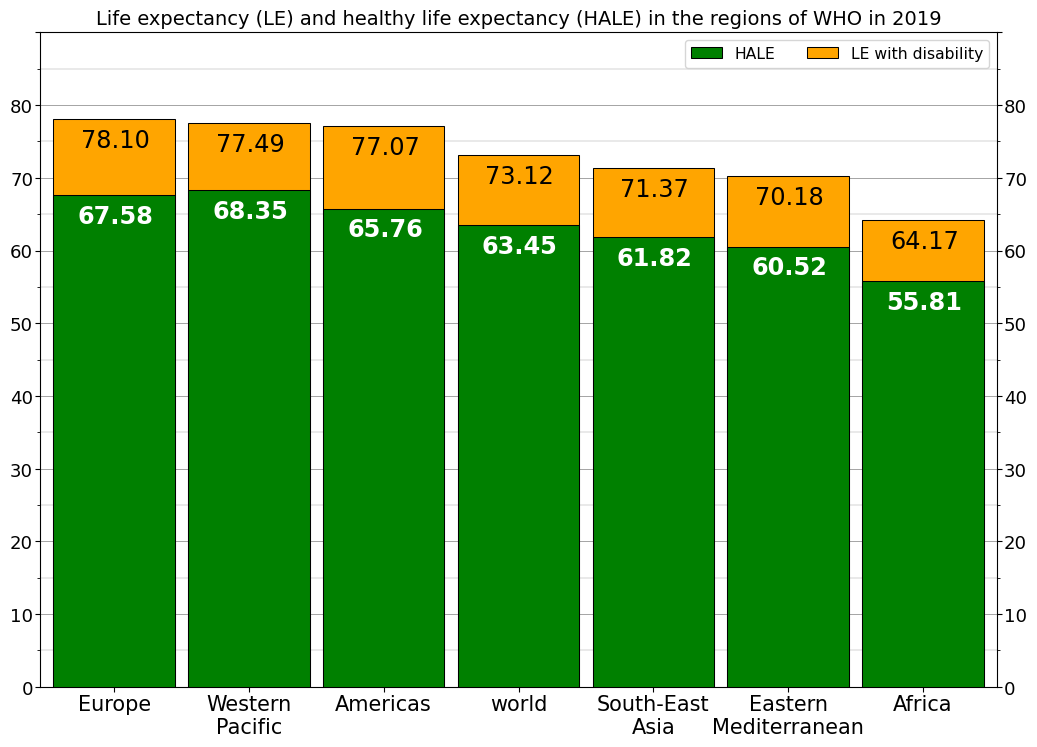

In [59]:
columns_sorting=['LE_o', 'HALE_o']
figure_size = (14, 8.5) if (LANG=='ru') else (12.35, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in the regions of WHO in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ)\nв регионах ВОЗ в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru,
                  destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -WHO regions',
                  label_rotation=0, value_precision=2, size_text_on_chart='xx-large')

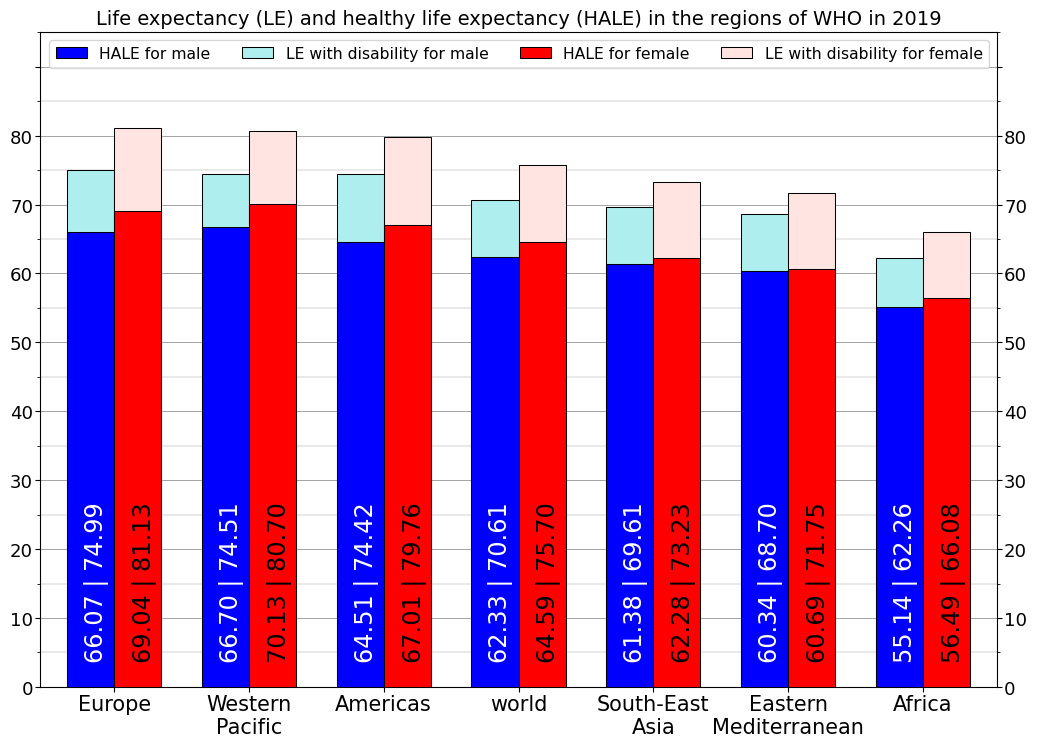

In [60]:
short_legend = (LANG=='ru')

compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, short_legend=short_legend, hide_upper_label=True,
                         destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -WHO regions -sex',
                         label_rotation=0, value_precision=2, size_text_on_chart='xx-large')

<br />

<br />
<br />

**income groups**<br>
*(just for interest, not for file)*

In [63]:
ls_countries = ['world', 'countries with\nhigh\nincome', 'countries with\nupper-middle\nincome',
                'countries with\nlower-middle\nincome', 'countries with\nlow\nincome']
df.loc[ls_countries].sort_values(by='LE_o', ascending=False)

,LE_o,LE_m,LE_f,LE_fΔm,HALE_o,HALE_m,HALE_f,HALE_fΔm,ratio_HALE_LE
,,,,,,,,,
countries with\nhigh\nincome,80.91,78.48,83.33,4.85,69.28,68.28,70.26,1.98,85.63
countries with\nupper-middle\nincome,75.67,72.73,78.72,5.99,66.42,64.88,68.01,3.13,87.78
world,73.12,70.61,75.70,5.09,63.45,62.33,64.59,2.26,86.78
countries with\nlower-middle\nincome,69.57,67.70,71.53,3.83,60.22,59.70,60.77,1.07,86.56
countries with\nlow\nincome,64.22,62.10,66.34,4.24,55.89,54.98,56.81,1.83,87.03


Number of items: 5


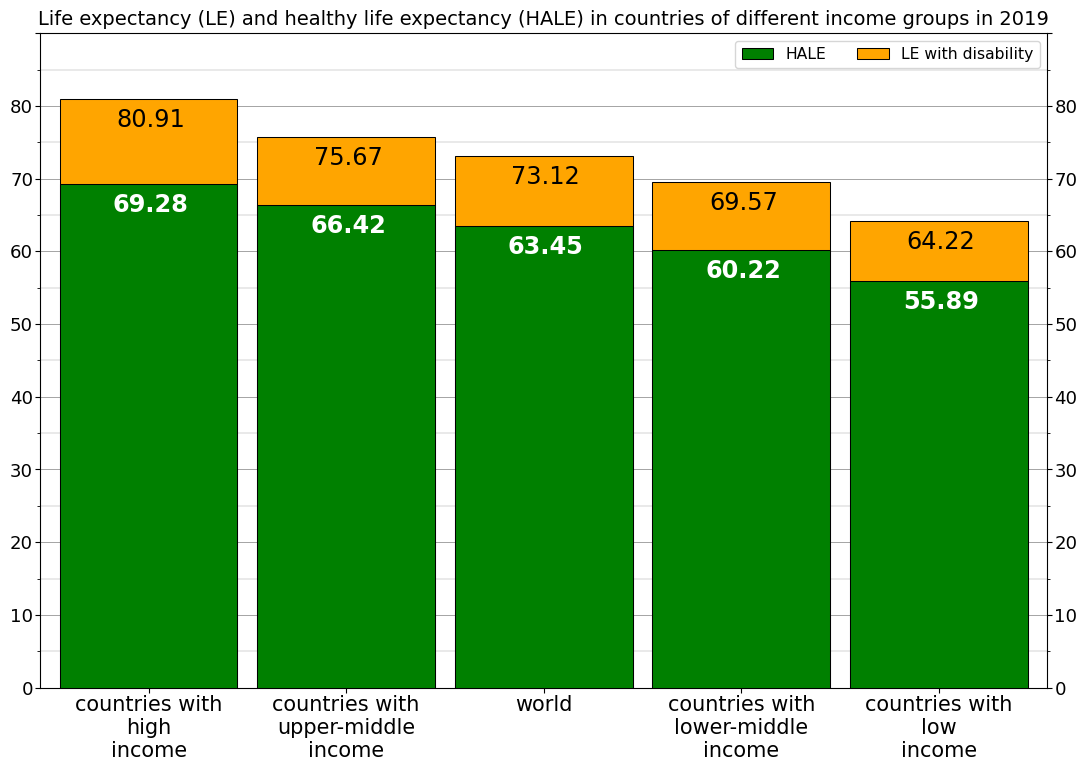

In [64]:
columns_sorting=['LE_o', 'HALE_o']
figure_size=(14, 8.5) if (LANG=='ru') else (13, 8.5)
title_en = 'Life expectancy (LE) and healthy life expectancy (HALE) in countries of different income groups in 2019'
title_ru = 'Ожидаемая продолжительность жизни (ОПЖ) и ожидаемая продолжительность здоровой жизни (ОПЗЖ)\nв странах с различным уровнем дохода населения в 2019 году'

compare_countries(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                  title_en=title_en, title_ru=title_ru,
                  destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -income groups',
                  label_rotation=0, value_precision=2, size_text_on_chart='xx-large')

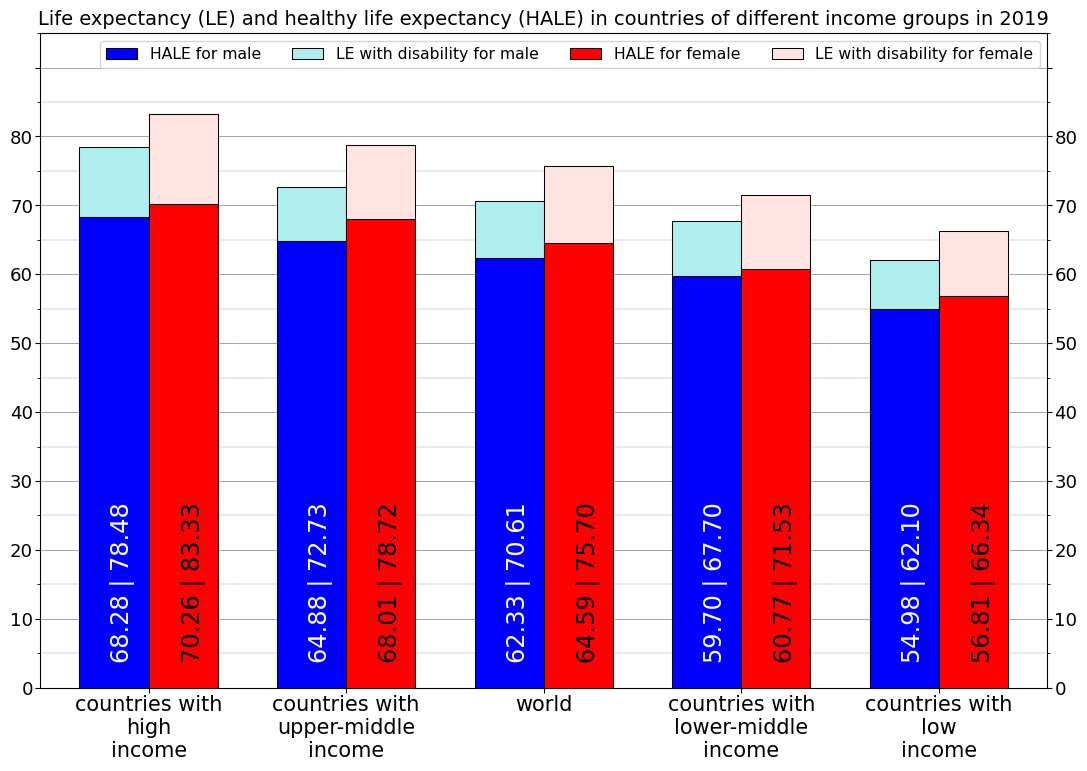

In [65]:
short_legend = (LANG=='ru')

compare_countries_by_sex(df, ls_countries, columns_sorting=columns_sorting, figure_size=figure_size, lang=LANG,
                         title_en=title_en, title_ru=title_ru, short_legend=short_legend, hide_upper_label=True,
                         destination=DESTINATION_OUTPUT, file_name='Healthy life expectancy bar chart -income groups -sex',
                         label_rotation=0, value_precision=2, size_text_on_chart='xx-large')

<br />
<br />

In [67]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)